# EDA — Tipos Interes

---
## 0. Configuración del Dataset

In [31]:
# ============================================================
# CONFIGURACIÓN: TIPOS_INTERES
# ============================================================

DATASET_CONFIG = {
    'nombre': 'tipos_interes',
    'archivo': 'interes_legal_interes_demora_tributaria.csv',
    'frecuencia_original': 'mensual',
    'col_fecha': 'fecha',
    'variable_principal': 'interes_legal',
    'variables_desgloses': [
        'interes_demora_efectos_tributarios',
    ],
    'columnas_numericas': [
        'interes_legal',
        'interes_demora_efectos_tributarios',
    ],
    'unidades': '% anual',
    'notas': 'BOE. Interés legal del dinero e interés de demora tributaria. Mensual desde 1973.',
}

VAR_PRINCIPAL = DATASET_CONFIG['variable_principal']
NOMBRE        = DATASET_CONFIG['nombre']
UNIDADES      = DATASET_CONFIG['unidades']

PERIODO_ESTACIONAL = {
    'trimestral': 4,
    'mensual': 12,
    'diaria': 365,
}[DATASET_CONFIG['frecuencia_original']]

LAGS_ACF = {
    'trimestral': 16,
    'mensual': 36,
    'diaria': 60,
}[DATASET_CONFIG['frecuencia_original']]

print(f'Dataset configurado: {NOMBRE}')
print(f'Variable principal:  {VAR_PRINCIPAL}')
print(f'Frecuencia:          {DATASET_CONFIG["frecuencia_original"]}')
print(f'Periodo estacional:  {PERIODO_ESTACIONAL}')

Dataset configurado: tipos_interes
Variable principal:  interes_legal
Frecuencia:          mensual
Periodo estacional:  12


---
## Imports

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import warnings
from pathlib import Path
from scipy import stats

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)

RUTA_BASE = Path(r'C:\Users\marco\PycharmProjects\TFM_Marcos\Datasets')

COLOR_PRINCIPAL = '#5E35B1'
COLORES_DESGLOSES = ['#00897B', '#FF7043', '#FFC107', '#1565C0', '#AD1457']

EVENTOS = {
    '1986-01-01': 'Entrada UE',
    '1999-01-01': 'Euro',
    '2008-09-01': 'Crisis\nfinanciera',
    '2012-01-01': 'Crisis\ndeuda',
    '2020-03-01': 'COVID-19',
}

---
## 1. Carga y Diagnóstico Básico

In [33]:
ruta = RUTA_BASE / DATASET_CONFIG['archivo']
df = pd.read_csv(ruta)
df[DATASET_CONFIG['col_fecha']] = pd.to_datetime(df[DATASET_CONFIG['col_fecha']])
df = df.set_index(DATASET_CONFIG['col_fecha']).sort_index()

for col in DATASET_CONFIG['columnas_numericas']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Dataset: {NOMBRE}')
print(f'Notas:   {DATASET_CONFIG["notas"]}')
print('=' * 60)
print(f'Shape:          {df.shape}')
print(f'Rango temporal: {df.index.min().date()} a {df.index.max().date()}')
print(f'Observaciones:  {len(df)}')
print(f'Columnas:       {list(df.columns)}')

Dataset: tipos_interes
Notas:   BOE. Interés legal del dinero e interés de demora tributaria. Mensual desde 1973.
Shape:          (616, 5)
Rango temporal: 1974-07-01 a 2025-10-01
Observaciones:  616
Columnas:       ['interes_legal', 'interes_demora_efectos_tributarios', 'año', 'trimestre', 'periodo']


In [34]:
print('Primeras 3 filas:')
display(df.head(3))
print('\nÚltimas 3 filas:')
display(df.tail(3))

Primeras 3 filas:


,interes_legal,interes_demora_efectos_tributarios,año,trimestre,periodo
fecha,,,,,
1974-07-01,4.000,4.000,1974,3,1974Q3
1974-08-01,4.000,4.000,1974,3,1974Q3
1974-09-01,4.000,4.000,1974,3,1974Q3



Últimas 3 filas:


,interes_legal,interes_demora_efectos_tributarios,año,trimestre,periodo
fecha,,,,,
2025-08-01,3.250,4.062,2025,3,2025Q3
2025-09-01,3.250,4.062,2025,3,2025Q3
2025-10-01,3.250,4.062,2025,4,2025Q4


In [35]:
cols_num = DATASET_CONFIG['columnas_numericas']
cols_num = [c for c in cols_num if c in df.columns]

nulos = pd.DataFrame({
    'n_nulos': df[cols_num].isnull().sum(),
    'pct_nulos': df[cols_num].isnull().mean() * 100,
    'primer_valido': [df[c].first_valid_index() for c in cols_num],
    'ultimo_valido': [df[c].last_valid_index() for c in cols_num],
}).round(2)

print('Diagnóstico de valores faltantes:')
display(nulos)

n_dupl = df.index.duplicated().sum()
print(f'\nDuplicados de fecha: {n_dupl}')

Diagnóstico de valores faltantes:


,n_nulos,pct_nulos,primer_valido,ultimo_valido
interes_legal,0,0.000,1974-07-01,2025-10-01
interes_demora_efectos_tributarios,0,0.000,1974-07-01,2025-10-01



Duplicados de fecha: 0


In [36]:
if len(df) > 1:
    diffs = df.index.to_series().diff().dropna()
    print(f'Intervalo mediano entre observaciones: {diffs.median()}')
    print(f'Intervalo mínimo:                      {diffs.min()}')
    print(f'Intervalo máximo:                      {diffs.max()}')

    umbral = diffs.median() * 2
    huecos = diffs[diffs > umbral]
    if len(huecos) > 0:
        print(f'\nHuecos temporales detectados ({len(huecos)}):')
        print(huecos)

Intervalo mediano entre observaciones: 31 days 00:00:00
Intervalo mínimo:                      28 days 00:00:00
Intervalo máximo:                      31 days 00:00:00


---
## 2. Series Temporales

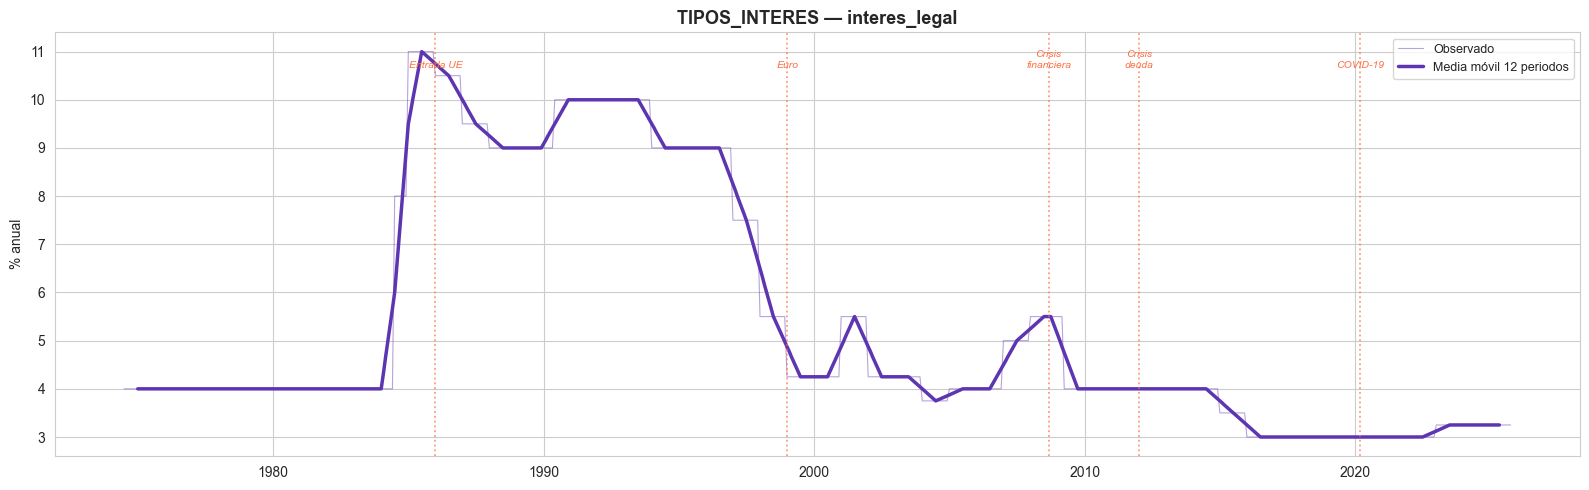

Mín: 3.00  (2016-01-01)
Máx: 11.00  (1985-01-01)


In [37]:
ventana_mm = PERIODO_ESTACIONAL

fig, ax = plt.subplots(figsize=(16, 5))

y = df[VAR_PRINCIPAL].dropna()
mm = y.rolling(ventana_mm, center=True).mean()

ax.plot(y.index, y, color=COLOR_PRINCIPAL, lw=0.8, alpha=0.45, label='Observado')
ax.plot(y.index, mm, color=COLOR_PRINCIPAL, lw=2.5,
        label=f'Media móvil {ventana_mm} periodos')

y_max = y.max()
for fecha_str, texto in EVENTOS.items():
    fecha_ev = pd.Timestamp(fecha_str)
    if y.index.min() <= fecha_ev <= y.index.max():
        ax.axvline(fecha_ev, color='#FF7043', linestyle=':', lw=1.3, alpha=0.7)
        ax.text(fecha_ev, y_max * 0.97, texto,
                ha='center', fontsize=7.5, color='#FF7043', fontstyle='italic')

ax.set_title(f'{NOMBRE.upper()} — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')
ax.set_ylabel(UNIDADES, fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Mín: {y.min():.2f}  ({y.idxmin().date()})')
print(f'Máx: {y.max():.2f}  ({y.idxmax().date()})')

### Análisis:

El `interes_legal` (tipo de interés legal del dinero) es un tipo regulado que se fija por decreto a través de la Ley de Presupuestos Generales del Estado, no un tipo de mercado, y su evolución temporal es una función escalonada con cambios discretos infrecuentes. Desde 1999, con la delegación de la política monetaria al BCE, su fijación se alinea de facto con el entorno de tipos del BCE, lo que lo convierte en la mejor aproximación disponible a las condiciones monetarias para el conjunto de la muestra, dado que el Euríbor y el tipo de intervención del BCE solo existen desde 1999 y no cubren el tramo 1975-1998.

La serie oscila entre un mínimo de 3,00% vigente desde enero de 2016 y un máximo de 11,00% vigente desde enero de 1985. Se distinguen tres regímenes principales. El primero, entre 1975 y 1984, mantiene el tipo estable en 4,00% durante casi una década, reflejando la rigidez regulatoria de la Transición en un contexto de inflación de dos dígitos que hacía el tipo legal real significativamente negativo. El segundo, entre 1985 y 1999, es el de mayor nivel y volatilidad: el tipo sube abruptamente a 11,00% en 1985, desciende por escalones hasta 9,00% en torno a 1988, rebota a 10,00% en 1990-1994, y cae de forma pronunciada hasta aproximadamente 4,25% en el periodo de convergencia hacia el euro, reflejando la disciplina monetaria del SME y los criterios de Maastricht. El tercero, desde 1999, oscila en una banda más estrecha de 3,00% a 5,50%, con un repunte hasta 5,50% en 2007-2008 vinculado al ciclo alcista del BCE, seguido de un descenso gradual hasta el mínimo histórico de 3,00% en 2016, donde permanece estable hasta el final de la muestra pese al ciclo de subidas de 2022-2024, lo que sugiere un desacoplamiento reciente entre el tipo legal y el tipo de intervención del BCE.

Su naturaleza escalonada y su baja frecuencia de cambio definen el rasgo central de esta variable: el nivel del tipo, más que su variación, es lo informativo, pues cada escalón captura un régimen monetario persistente y un entorno de coste del crédito estable. Esta caracterización como variable de régimen queda documentada como hallazgo y condiciona el tratamiento posterior de la serie, que se resuelve en la fase de feature engineering.

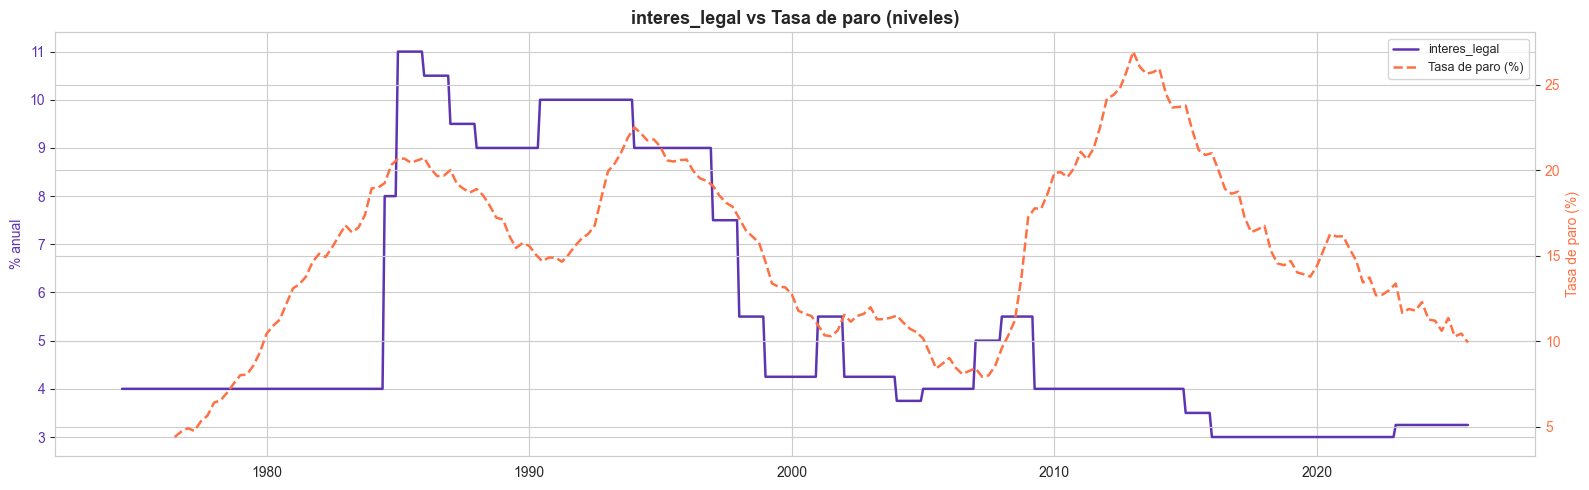

In [38]:
# Comparación de niveles con la tasa de paro (antes de analizar estacionariedad)
ruta_paro_s2 = RUTA_BASE / 'parados_sexo_edad.csv'
df_paro_s2 = pd.read_csv(ruta_paro_s2)
df_paro_s2['fecha'] = pd.to_datetime(df_paro_s2['fecha'])
df_paro_s2 = df_paro_s2.set_index('fecha').sort_index()
tasa_paro_s2 = pd.to_numeric(df_paro_s2['tasa_paro_ambos_sexos_total'], errors='coerce').dropna()

y = df[VAR_PRINCIPAL].dropna()

fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()
ax1.plot(y.index, y, color=COLOR_PRINCIPAL, lw=1.8, label=VAR_PRINCIPAL)
ax2.plot(tasa_paro_s2.index, tasa_paro_s2, color='#FF7043', lw=1.8, linestyle='--', label='Tasa de paro (%)')
ax1.set_ylabel(UNIDADES, color=COLOR_PRINCIPAL, fontsize=10)
ax2.set_ylabel('Tasa de paro (%)', color='#FF7043', fontsize=10)
ax1.tick_params(axis='y', labelcolor=COLOR_PRINCIPAL)
ax2.tick_params(axis='y', labelcolor='#FF7043')
ax1.set_title(f'{VAR_PRINCIPAL} vs Tasa de paro (niveles)', fontsize=13, fontweight='bold')
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=9, loc='best')
plt.tight_layout()
plt.show()


### Análisis:

La relación en niveles entre el `interes_legal` y la tasa de paro está dominada por la coincidencia de regímenes, no por una transmisión estable. El tipo legal es una función escalonada: fijo en 4% hasta 1984, salto a 11% en 1985 y descenso por escalones hasta la banda baja de 3-5,5% desde 1999, donde permanece. La tasa de paro, sin esa estructura discreta, recorre sus ciclos, con picos de 21% en 1985, 24% en 1994 y 27% en 2013. El co-movimiento aparente cambia por tramos: entre 1975 y 1985 ambas suben (el tipo de 4% a 11%, el paro de 5% a 21%); entre 1995 y 2007 ambas descienden en paralelo (el tipo de 9% a 4%, el paro de 24% a 8%), aunque por causas distintas, la convergencia hacia el euro y el boom económico respectivamente; y desde 2008 el tipo permanece estable en su banda baja mientras el paro describe sus dos grandes ciclos con total independencia del nivel del tipo. La asociación positiva que sugiere el nivel, con los tipos altos coincidiendo con el paro alto en 1985-1998, es una coincidencia histórica entre el régimen de tipos altos y el periodo de desempleo estructuralmente elevado, no una relación causal; el análisis cuantitativo de la sección 9 se realiza sobre la forma estacionaria, la variación del tipo, y confirma que esa correlación de nivel era espuria.

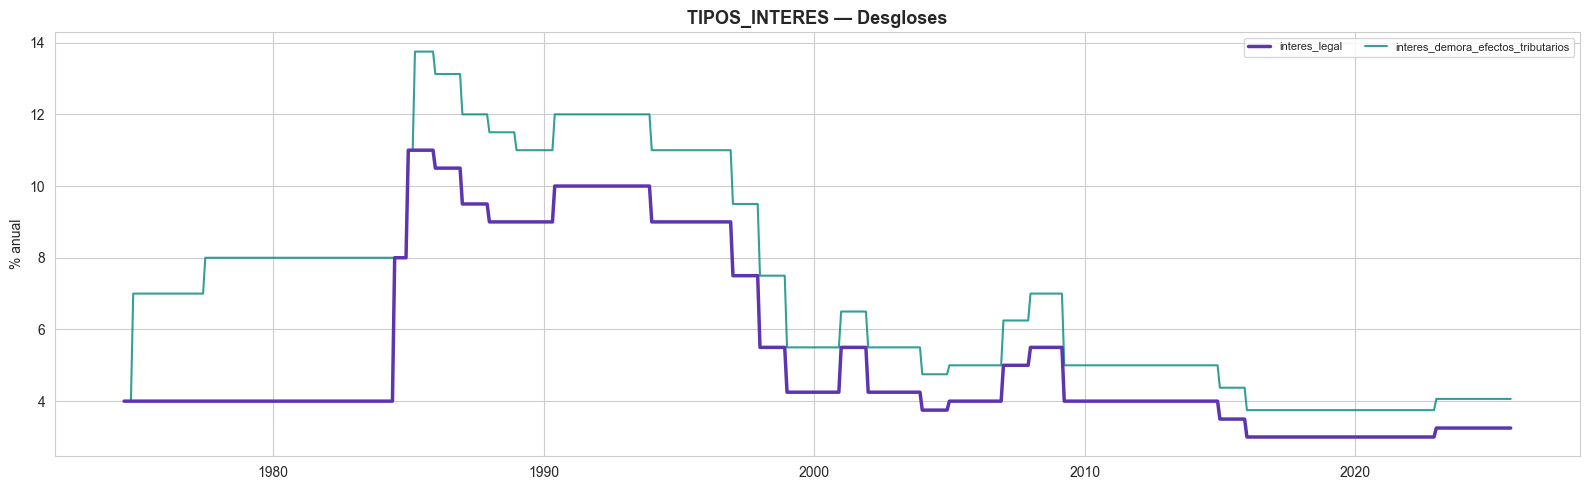

In [39]:
desgloses = [c for c in DATASET_CONFIG.get('variables_desgloses', []) if c in df.columns]

if desgloses:
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(y.index, y, color=COLOR_PRINCIPAL, lw=2.5, label=VAR_PRINCIPAL, zorder=5)

    for col, color in zip(desgloses, COLORES_DESGLOSES):
        serie = df[col].dropna()
        ax.plot(serie.index, serie, color=color, lw=1.5, alpha=0.8, label=col)

    ax.set_title(f'{NOMBRE.upper()} — Desgloses', fontsize=13, fontweight='bold')
    ax.set_ylabel(UNIDADES, fontsize=10)
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

### Análisis:

El desglose confirma que ambos tipos regulados, `interes_legal` e `interes_demora_efectos_tributarios`, siguen trayectorias paralelas a lo largo de toda la muestra con un spread persistentemente positivo a favor del tipo de demora. El `interes_demora_efectos_tributarios` se sitúa sistemáticamente por encima del `interes_legal`, con un diferencial que varía entre aproximadamente 2 y 4 puntos porcentuales según el periodo: más amplio durante la fase de tipos altos de 1985-1995 (donde el tipo de demora alcanza el máximo de aproximadamente 14% frente al 11% del tipo legal) y más estrecho en el régimen post-2000 (donde ambos convergen hacia un diferencial estable de aproximadamente 1 punto porcentual al final de la muestra, con el tipo legal en 3,00% y el de demora en torno a 4,00%).

La colinealidad entre ambas series es muy elevada: los escalones se producen en las mismas fechas o con retardos mínimos, y la dirección de los cambios es siempre la misma. Esto implica que incluir ambas como regresores en un modelo predictivo del paro no aportaría información incremental: una de las dos bastaría como proxy del régimen de tipos regulados. El `interes_legal` es la elección natural por ser el tipo de referencia más general y el que afecta a un abanico más amplio de operaciones económicas (indemnizaciones, préstamos sin tipo pactado, relaciones entre particulares), mientras que el tipo de demora tributaria es específico de las obligaciones con la Agencia Tributaria y tiene menor alcance macroeconómico. El spread entre ambos podría tener interés como variable auxiliar si captase señales de política fiscal diferenciadas, pero su estabilidad a lo largo de la muestra sugiere que no aporta información adicional a la contenida en el tipo legal.

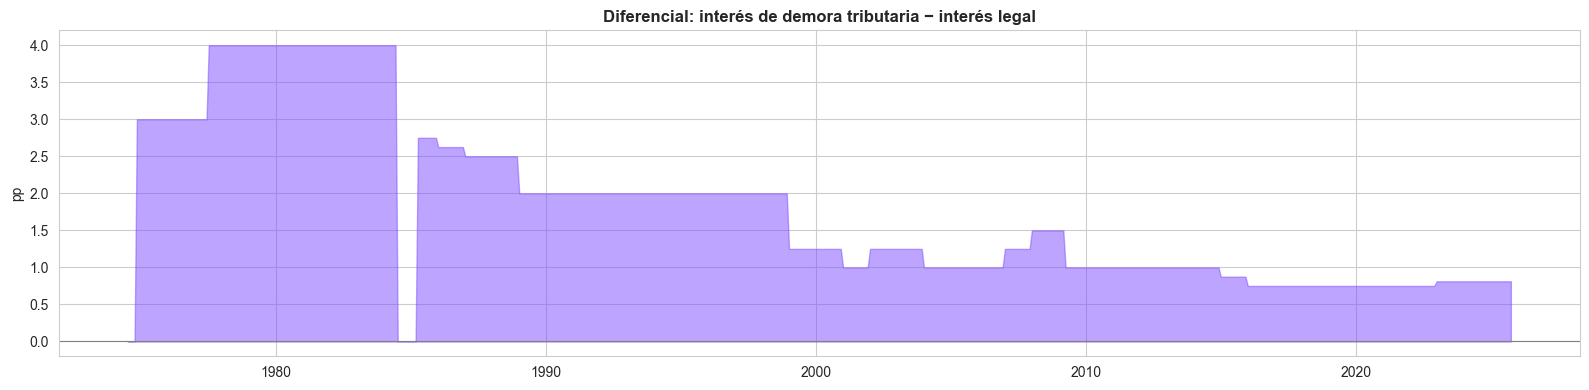

In [40]:
# Spread: interés de demora − interés legal
if 'interes_demora_efectos_tributarios' in df.columns and 'interes_legal' in df.columns:
    spread = df['interes_demora_efectos_tributarios'] - df['interes_legal']

    fig, ax = plt.subplots(figsize=(16, 4))
    ax.fill_between(spread.index, spread, 0, color='#7C4DFF', alpha=0.5)
    ax.axhline(0, color='gray', lw=0.8)
    ax.set_title('Diferencial: interés de demora tributaria − interés legal', fontsize=12, fontweight='bold')
    ax.set_ylabel('pp', fontsize=10)
    plt.tight_layout()
    plt.show()

### Análisis:

El diferencial confirma cuantitativamente la tendencia descendente anticipada en el análisis de desgloses. El spread parte de 3,0-4,0 puntos porcentuales en el periodo 1975-1984, se comprime a 2,5-2,75 puntos durante la fase de tipos altos de 1985-1995, y se reduce progresivamente hasta estabilizarse en torno a 0,75 puntos desde 2015 hasta el final de la muestra. La convergencia es prácticamente monótona salvo por un repunte puntual hasta 1,5 puntos en torno a 2008-2009.

La tendencia descendente del spread refleja la progresiva armonización legislativa del régimen sancionador tributario con el tipo de interés de referencia: a medida que los tipos legales se han comprimido hacia niveles de 3-4%, el legislador ha reducido proporcionalmente el recargo de demora, manteniendo su función penalizadora pero sin la amplitud de los años 80 cuando el diferencial de 4 puntos sobre un tipo legal de 4% suponía prácticamente duplicar la referencia. Para la modelización, este gráfico refuerza la conclusión anterior: el spread no aporta información adicional al `interes_legal` dado su perfil descendente estable y sin variación cíclica asociable al mercado laboral.

---
## 3. Distribución y Outliers

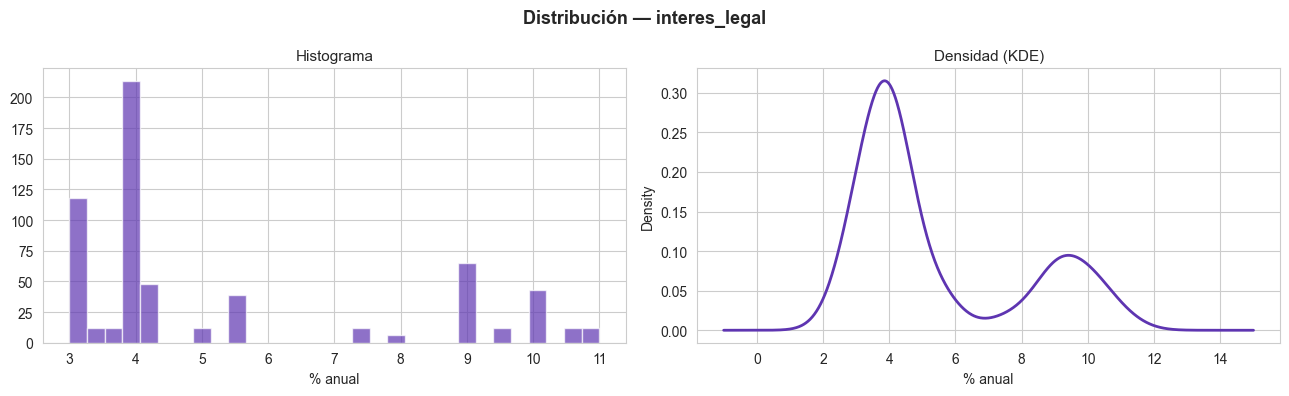

Asimetría (skewness): 1.016
Curtosis:             -0.608


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Distribución — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

axes[0].hist(y, bins=30, color=COLOR_PRINCIPAL, alpha=0.7, edgecolor='white')
axes[0].set_xlabel(UNIDADES, fontsize=10)
axes[0].set_title('Histograma', fontsize=11)

y.plot.kde(ax=axes[1], color=COLOR_PRINCIPAL, lw=2)
axes[1].set_xlabel(UNIDADES, fontsize=10)
axes[1].set_title('Densidad (KDE)', fontsize=11)

plt.tight_layout()
plt.show()

print(f'Asimetría (skewness): {y.skew():.3f}')
print(f'Curtosis:             {y.kurtosis():.3f}')

### Análisis:

La distribución del `interes_legal` presenta una estructura bimodal con dos masas de observaciones separadas por un valle pronunciado entre aproximadamente 6% y 8% donde apenas hay observaciones, aunque las dos modas difieren sustancialmente en densidad. La moda dominante se sitúa en torno a 3-4% y concentra la mayor parte de las observaciones, correspondiente a los dos periodos de tipos bajos: 1975-1984 (tipo fijo de 4%) y 1999-2025 (banda de 3-5,5%). La moda secundaria en torno a 9-11%, con una densidad notablemente inferior, agrupa las observaciones del régimen de tipos altos de 1985-1998, con barras separadas que reflejan los escalones discretos del tipo durante ese periodo.

La asimetría positiva de 1,016 refleja precisamente esta asimetría entre modas: la moda secundaria de tipos altos genera una cola derecha pronunciada respecto al centro de masa de la distribución, anclado en la moda dominante de tipos bajos. La curtosis negativa de -0,608 confirma el reparto de masa entre los dos extremos del rango con escasas observaciones en el centro, el mismo patrón platicúrtico documentado para el `pib_pm` (-1,496), aunque de menor intensidad. La naturaleza escalonada de la serie amplifica visualmente la separación entre modas: cada escalón genera una barra de frecuencia concentrada en un valor discreto en lugar de distribuirse de forma suave.

Esta estructura refuerza la lectura del `interes_legal` como variable de régimen más que como serie continua. Los dos clusters corresponden a los dos regímenes monetarios documentados en la serie principal (alta inflación pre-convergencia y estabilidad post-euro), y la distancia entre ambas modas, de aproximadamente 6 puntos porcentuales, cuantifica la magnitud del cambio estructural en las condiciones de financiación de la economía española entre ambos periodos.

In [42]:
Q1, Q3 = y.quantile(0.25), y.quantile(0.75)
IQR = Q3 - Q1
limite_inf_iqr = Q1 - 1.5 * IQR
limite_sup_iqr = Q3 + 1.5 * IQR

z_scores = np.abs(stats.zscore(y.dropna()))
outliers_z = y[z_scores > 3]
outliers_iqr = y[(y < limite_inf_iqr) | (y > limite_sup_iqr)]

print(f'Outliers por IQR  (1.5×): {len(outliers_iqr)}')
print(f'Outliers por z-score (>3): {len(outliers_z)}')

extremos = pd.concat([
    y.nsmallest(5).rename('valor'),
    y.nlargest(5).rename('valor')
]).sort_values()

print('\n10 valores extremos (5 mínimos + 5 máximos):')
print(extremos.to_frame().reset_index().to_string(index=False))

Outliers por IQR  (1.5×): 0
Outliers por z-score (>3): 0

10 valores extremos (5 mínimos + 5 máximos):
     fecha  valor
2016-01-01  3.000
2016-02-01  3.000
2016-03-01  3.000
2016-04-01  3.000
2016-05-01  3.000
1985-01-01 11.000
1985-02-01 11.000
1985-03-01 11.000
1985-04-01 11.000
1985-05-01 11.000


### Análisis:

La ausencia de outliers por ambos criterios es coherente con la naturaleza discreta y acotada de la serie. El `interes_legal` toma un número reducido de valores enteros o semienteros entre 3% y 11%, todos ellos observados durante periodos prolongados, lo que genera una distribución sin colas extremas en sentido estadístico: el rango intercuartílico cubre la mayor parte del recorrido de la serie y el z-score no detecta anomalías porque la varianza total ya incorpora la distancia entre los dos regímenes.

Los 10 valores extremos reflejan directamente los dos escalones de mayor duración en los extremos del rango: el mínimo histórico de 3,00% se mantiene de forma ininterrumpida desde enero de 2016, y el máximo de 11,00% estuvo vigente desde enero de 1985. Ambos grupos son extremos temporales de la serie, no anomalías, y su aparición en enero de cada año confirma que los cambios del tipo legal se producen siempre en el primer mes del ejercicio presupuestario, coherente con su fijación mediante Ley de Presupuestos Generales del Estado.

In [43]:
if DATASET_CONFIG['frecuencia_original'] == 'trimestral':
    y_periodo = y.index.quarter.map({1:'T1', 2:'T2', 3:'T3', 4:'T4'})
    titulo_grupo = 'Trimestre'
    orden_periodos = ['T1', 'T2', 'T3', 'T4']
elif DATASET_CONFIG['frecuencia_original'] == 'mensual':
    meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
    y_periodo = y.index.month.map({i+1: m for i, m in enumerate(meses)})
    titulo_grupo = 'Mes'
    orden_periodos = meses
else:
    meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
    y_periodo = y.index.month.map({i+1: m for i, m in enumerate(meses)})
    titulo_grupo = 'Mes'
    orden_periodos = meses

colores_bp = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107',
               '#1565C0', '#AD1457', '#2E7D32', '#E65100',
               '#6A1B9A', '#00695C', '#F57F17', '#37474F']

df_box = pd.DataFrame({
    'periodo': y_periodo.values,
    'valor': y.values,
    'fecha': y.index.strftime('%Y-%m-%d'),
})
df_box['periodo'] = pd.Categorical(df_box['periodo'],
                                    categories=[p for p in orden_periodos if p in df_box['periodo'].values],
                                    ordered=True)

fig = px.box(
    df_box, x='periodo', y='valor', color='periodo',
    hover_data=['fecha'],
    title=f'Distribución por {titulo_grupo} — {VAR_PRINCIPAL}',
    labels={'valor': UNIDADES, 'periodo': titulo_grupo, 'fecha': 'Fecha'},
    color_discrete_sequence=colores_bp,
    category_orders={'periodo': orden_periodos},
)
fig.update_layout(showlegend=False, height=420)
fig.show()

### Análisis:

La distribución por mes del `interes_legal` no presenta estacionalidad alguna, como era de esperar para un tipo regulado que se fija con carácter anual y permanece constante durante todo el ejercicio presupuestario. Las 12 cajas son prácticamente idénticas en mediana (en torno a 6%), rango intercuartílico y extensión de bigotes, con una ligera asimetría visual en noviembre y diciembre que no es estacional sino un artefacto de la discreción de la serie: en los meses finales del año no se producen cambios de tipo (que siempre ocurren en enero), por lo que las observaciones de noviembre y diciembre reflejan siempre el tipo vigente durante ese ejercicio, sin la variación que enero puede mostrar al incorporar el nuevo tipo aprobado en los presupuestos. Esta diferencia es mínima y no altera la conclusión: el `interes_legal` carece de patrón estacional mensual y el resampleo trimestral mediante media no introduce ni elimina variación artificial.

---
## 4. Estacionalidad

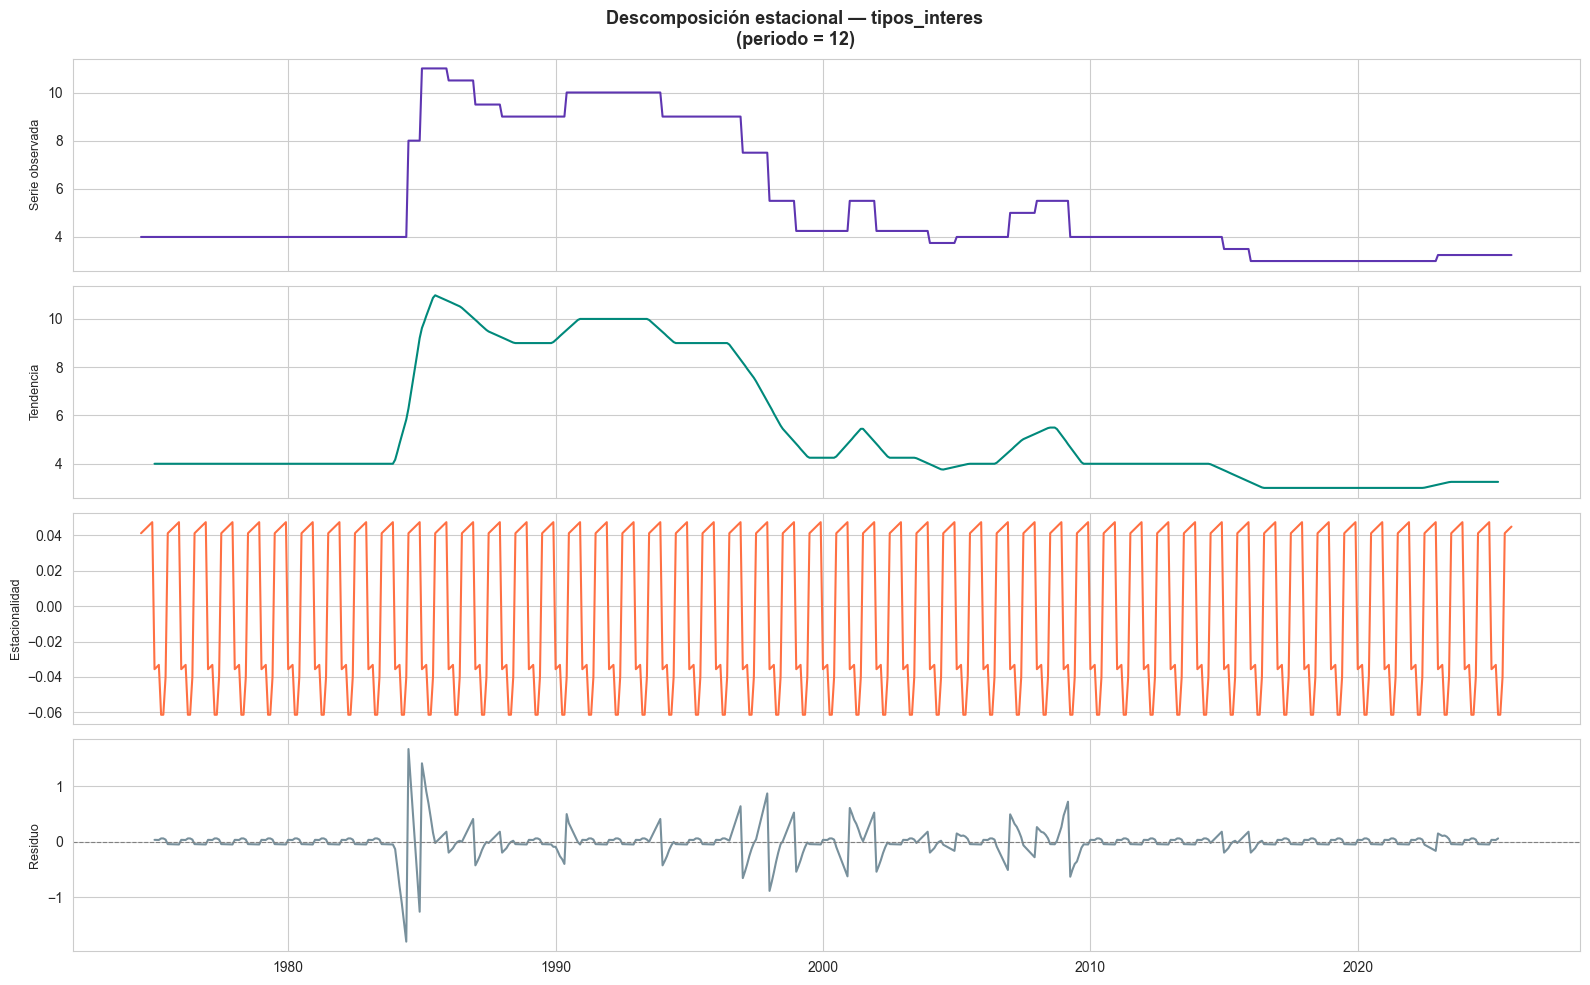

In [44]:
y_descomp = y.dropna()

if len(y_descomp) >= 2 * PERIODO_ESTACIONAL:
    descomp = seasonal_decompose(y_descomp, model='additive', period=PERIODO_ESTACIONAL)

    fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
    fig.suptitle(f'Descomposición estacional — {NOMBRE}\n(periodo = {PERIODO_ESTACIONAL})',
                 fontsize=13, fontweight='bold')

    componentes = [
        ('Serie observada', descomp.observed, COLOR_PRINCIPAL),
        ('Tendencia', descomp.trend, '#00897B'),
        ('Estacionalidad', descomp.seasonal, '#FF7043'),
        ('Residuo', descomp.resid, '#78909C'),
    ]

    for ax, (titulo, datos, color) in zip(axes, componentes):
        ax.plot(datos.index, datos, color=color, lw=1.5)
        ax.set_ylabel(titulo, fontsize=9)
        if titulo == 'Residuo':
            ax.axhline(0, color='gray', linestyle='--', lw=0.8)

    plt.tight_layout()
    plt.show()
else:
    print(f'Serie demasiado corta para descomposición (necesita ≥ {2*PERIODO_ESTACIONAL} obs, tiene {len(y_descomp)})')

### Análisis:

La descomposición STL con periodo 12 sobre el `interes_legal` confirma lo anticipado en el boxplot mensual: la naturaleza escalonada de la serie hace que el filtro, diseñado para series continuas, interprete los cambios discretos de una forma que conviene entender correctamente.

La tendencia replica la serie observada con un suavizado que redondea los escalones en transiciones graduales: los saltos abruptos de 1985 (de 4% a 11%) y los descensos escalonados posteriores aparecen como curvas en lugar de ángulos rectos. Esta suavización no refleja una dinámica económica subyacente sino el comportamiento del filtro de media móvil ante cambios discretos. La tendencia es el único componente que captura información real de la serie.

El componente estacional presenta una amplitud de aproximadamente ±0,06 puntos porcentuales, absolutamente negligible sobre una serie que oscila entre 3% y 11%. Su patrón regular y de amplitud constante es un artefacto del algoritmo STL que extrae mecánicamente un componente de periodo 12 aunque no exista estacionalidad económica real en la serie. Este componente debe ignorarse en cualquier interpretación sustantiva.

El residuo concentra los picos más informativos del gráfico: los valores extremos de aproximadamente ±1,5 puntos en torno a 1985-1986 corresponden al salto abrupto del tipo de 4% a 11%, que el filtro de tendencia no absorbe completamente en un único periodo y genera un residuo transitorio de gran magnitud. Los picos menores a lo largo del tramo 1986-2010 coinciden con cada cambio de escalón del tipo legal. A partir de 2010 los residuos son prácticamente nulos, coherente con la estabilización del tipo en el régimen de tipos bajos. Para la modelización, estos residuos no son perturbaciones económicas sino artefactos de la naturaleza discreta de la serie sobre un filtro continuo.

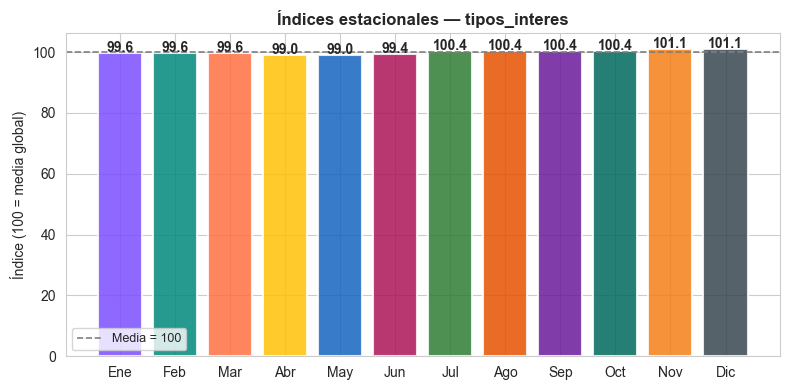

Índices estacionales:
Ene    99.600
Feb    99.600
Mar    99.600
Abr    99.000
May    99.000
Jun    99.400
Jul   100.400
Ago   100.400
Sep   100.400
Oct   100.400
Nov   101.100
Dic   101.100

Periodo con mayor tipos_interes: Nov (101.1)
Periodo con menor tipos_interes: Abr (99.0)


In [45]:
if DATASET_CONFIG['frecuencia_original'] in ('trimestral', 'mensual'):

    if DATASET_CONFIG['frecuencia_original'] == 'trimestral':
        grupo_idx = y.index.quarter
        etiq_idx = ['T1', 'T2', 'T3', 'T4']
    else:
        grupo_idx = y.index.month
        etiq_idx = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

    media_por_periodo = pd.Series(
        {p: y[grupo_idx == p].mean() for p in sorted(np.unique(grupo_idx))}
    )
    indice_estacional = (media_por_periodo / media_por_periodo.mean() * 100).round(1)
    indice_estacional.index = etiq_idx[:len(indice_estacional)]

    fig, ax = plt.subplots(figsize=(8, 4))
    colores_idx = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107',
                   '#1565C0', '#AD1457', '#2E7D32', '#E65100',
                   '#6A1B9A', '#00695C', '#F57F17', '#37474F']
    barras = ax.bar(indice_estacional.index, indice_estacional.values,
                    color=colores_idx[:len(indice_estacional)], edgecolor='white',
                    linewidth=1.5, alpha=0.85)
    ax.axhline(100, color='gray', linestyle='--', lw=1.2, label='Media = 100')
    ax.set_title(f'Índices estacionales — {NOMBRE}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Índice (100 = media global)', fontsize=10)
    for b, v in zip(barras, indice_estacional.values):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    print('Índices estacionales:')
    print(indice_estacional.to_string())
    print(f'\nPeriodo con mayor {NOMBRE}: {indice_estacional.idxmax()} ({indice_estacional.max():.1f})')
    print(f'Periodo con menor {NOMBRE}: {indice_estacional.idxmin()} ({indice_estacional.min():.1f})')

### Análisis:

Los índices estacionales confirman la ausencia de estacionalidad económica real en el `interes_legal`. El rango entre el mes de mayor índice (noviembre y diciembre, 101,1) y el de menor (abril y mayo, 99,0) es de apenas 2,1 puntos porcentuales, la amplitud más reducida de todas las variables analizadas junto al `HEUR_USD`. El patrón ligeramente ascendente a lo largo del año es un artefacto de la naturaleza escalonada de la serie sobre el filtro STL, no una estacionalidad económica interpretable. El resampleo trimestral no requiere corrección estacional.

---
## 5. Cambios Periodo a Periodo

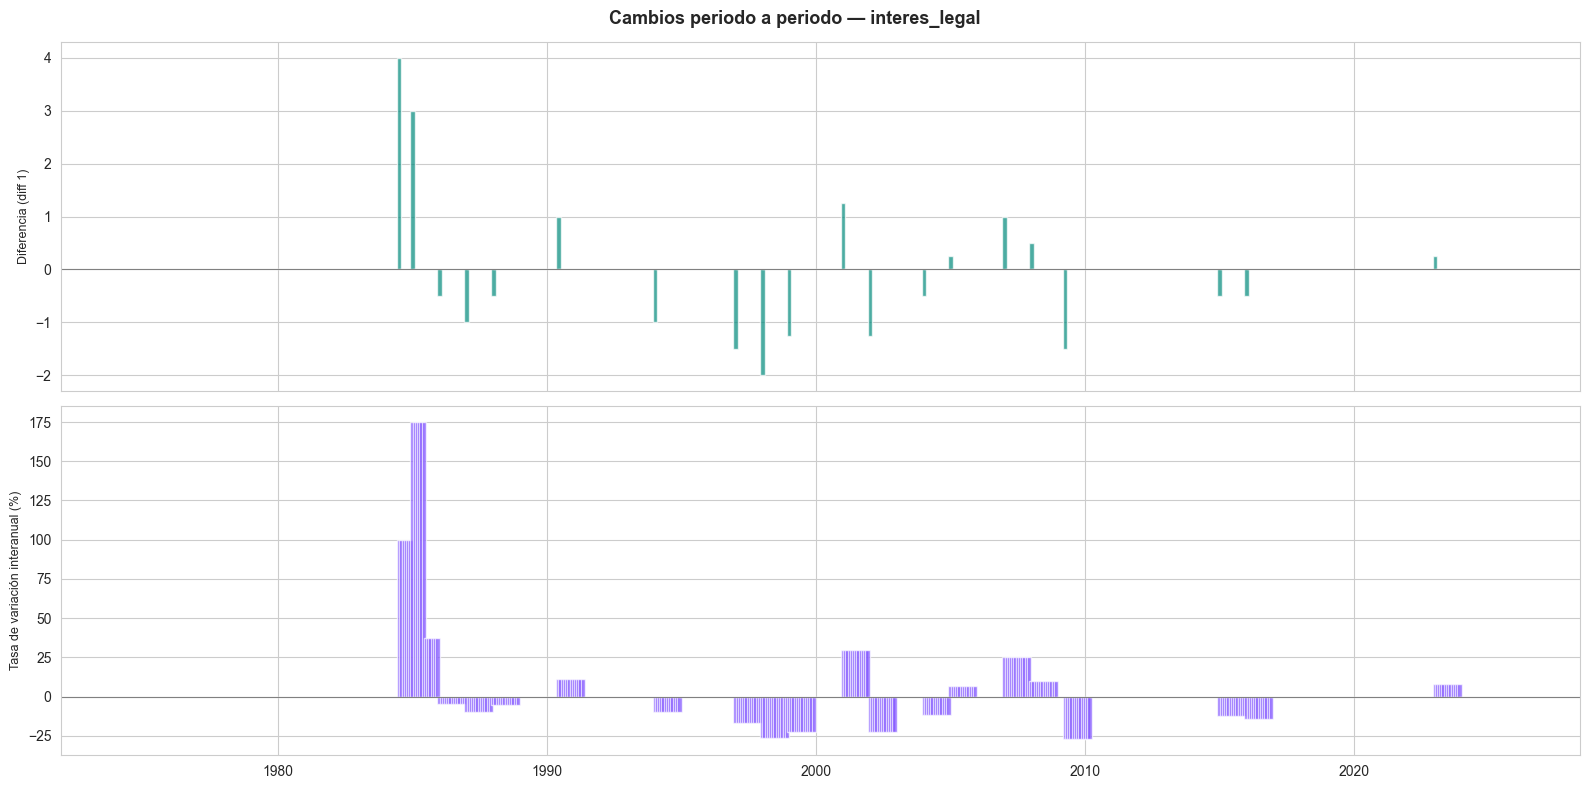

Estadísticas de la variación interanual (%):
count   604.000
mean      1.250
std      22.860
min     -27.270
25%       0.000
50%       0.000
75%       0.000
max     175.000


In [46]:
diff1 = y.diff(1).dropna()
diff_est = y.diff(PERIODO_ESTACIONAL).dropna()  # se usa en Sección 6 (stationarity test)
pct_yoy = y.pct_change(PERIODO_ESTACIONAL).dropna() * 100

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle(f'Cambios periodo a periodo — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

axes[0].bar(diff1.index, diff1, color='#00897B', alpha=0.7, width=60)
axes[0].axhline(0, color='gray', lw=0.8)
axes[0].set_ylabel('Diferencia (diff 1)', fontsize=9)

axes[1].bar(pct_yoy.index, pct_yoy, color='#7C4DFF', alpha=0.7, width=60)
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].set_ylabel('Tasa de variación interanual (%)', fontsize=9)

plt.tight_layout()
plt.show()

print('Estadísticas de la variación interanual (%):')
print(pct_yoy.describe().round(2).to_string())

### Análisis:

Los cambios periodo a periodo del `interes_legal` confirman visualmente su naturaleza de variable discreta con cambios infrecuentes. La diferencia primera (panel superior) es cero durante la gran mayoría de los meses de la muestra, con barras que aparecen únicamente en los momentos de cambio de escalón: los picos positivos en torno a 1985, los mayores de la serie con incrementos de hasta +4 puntos en un único mes, los descensos escalonados entre 1988 y 2000, y los ajustes menores del periodo 2000-2015. La estructura dispersa de estas barras cuantifica directamente la baja frecuencia de cambio ya documentada.

La variación interanual (panel inferior) amplifica esta imagen. Los estadísticos son directamente interpretables: la mediana de 0,000% y el percentil 75 de 0,000% indican que en más del 75% de los meses de la muestra el tipo legal era exactamente igual al del mismo mes del año anterior, es decir, no había habido ningún cambio en los doce meses previos. La media de 1,250% y la desviación típica de 22,860% están completamente dominadas por los episodios de cambio, con el máximo de 175% y el mínimo de -27,270% correspondiendo a los momentos de mayor variación relativa del tipo. Esta distribución, extremadamente concentrada en cero con colas largas, ilustra por qué la variación interanual porcentual no es una transformación adecuada para esta serie: aporta señal únicamente en los escasos meses de cambio, y el cambio porcentual de una tasa carece además de interpretación económica clara. La forma estacionaria adoptada es la diferencia absoluta en puntos.

---
## 6. Estacionariedad y Autocorrelación

In [47]:
def test_estacionariedad(serie, nombre_serie, regression='c'):
    s = serie.dropna()
    adf_stat, adf_p, _, _, _, _ = adfuller(s, autolag='AIC')
    kpss_stat, kpss_p, _, _ = kpss(s, regression=regression, nlags='auto')
    estacionaria = (adf_p < 0.05) and (kpss_p >= 0.05)
    return {
        'serie': nombre_serie,
        'regression': regression,
        'ADF_stat': round(adf_stat, 4),
        'ADF_p': round(adf_p, 4),
        'ADF_H0_rechaza': adf_p < 0.05,
        'KPSS_stat': round(kpss_stat, 4),
        'KPSS_p': round(kpss_p, 4),
        'KPSS_H0_rechaza': kpss_p < 0.05,
        'conclusion': 'ESTACIONARIA' if estacionaria else 'NO ESTACIONARIA',
    }

series_test = [
    (y, f'{VAR_PRINCIPAL} (nivel)', 'c'),
    (diff1, f'{VAR_PRINCIPAL} (diff 1)', 'c'),
    (diff_est, f'{VAR_PRINCIPAL} (diff {PERIODO_ESTACIONAL})', 'c'),
]

resultados_est = pd.DataFrame([test_estacionariedad(s, n, r) for s, n, r in series_test])

print('Tests de estacionariedad:')
print('=' * 85)
print(resultados_est.to_string(index=False))
print()
print('Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)')
for _, row in resultados_est.iterrows():
    h0_adf = 'rechaza H\u2080' if row['ADF_H0_rechaza'] else 'NO rechaza H\u2080'
    h0_kpss = 'rechaza H\u2080' if row['KPSS_H0_rechaza'] else 'NO rechaza H\u2080'
    print(f"  {row['serie']}  (KPSS regression='{row['regression']}')")
    print(f"    ADF  (H\u2080 = ra\u00edz unitaria):  stat={row['ADF_stat']:.3f}, p={row['ADF_p']:.4f} ({h0_adf})")
    print(f"    KPSS (H\u2080 = estacionaria):   stat={row['KPSS_stat']:.3f}, p={row['KPSS_p']:.4f} ({h0_kpss})")
    print(f"    \u2192 {row['conclusion']}")
    print()

Tests de estacionariedad:
                  serie regression  ADF_stat  ADF_p  ADF_H0_rechaza  KPSS_stat  KPSS_p  KPSS_H0_rechaza      conclusion
  interes_legal (nivel)          c    -1.677  0.443           False      1.286   0.010             True NO ESTACIONARIA
 interes_legal (diff 1)          c    -7.563  0.000            True      0.205   0.100            False    ESTACIONARIA
interes_legal (diff 12)          c    -4.014  0.001            True      0.184   0.100            False    ESTACIONARIA

Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)
  interes_legal (nivel)  (KPSS regression='c')
    ADF  (H₀ = raíz unitaria):  stat=-1.677, p=0.4428 (NO rechaza H₀)
    KPSS (H₀ = estacionaria):   stat=1.286, p=0.0100 (rechaza H₀)
    → NO ESTACIONARIA

  interes_legal (diff 1)  (KPSS regression='c')
    ADF  (H₀ = raíz unitaria):  stat=-7.563, p=0.0000 (rechaza H₀)
    KPSS (H₀ = estacionaria):   stat=0.205, p=0.1000 (NO rechaza H₀)
    → ESTACIONARIA

  interes_legal (d

### Análisis:

En niveles, ambos tests convergen en un diagnóstico claro de no estacionariedad: el ADF no rechaza la raíz unitaria (stat=-1,677, p=0,4428) y el KPSS rechaza la estacionariedad con uno de los estadísticos más elevados de las series analizadas (stat=1,286, p=0,0100). Este valor refleja la estructura escalonada de la serie: los periodos prolongados de tipo constante generan una varianza de corto plazo reducida, pero los saltos entre regímenes producen una no estacionariedad estructural que el KPSS detecta con contundencia. El uso de regresión sin tendencia es apropiado, dado que la serie no presenta tendencia monótona sino cambios de nivel entre regímenes.

Tanto la primera diferencia como la diferencia de orden 12 producen diagnósticos limpios de estacionariedad. En diff 1, el ADF rechaza contundentemente la raíz unitaria (stat=-7,563, p=0,0000) y el KPSS no rechaza la estacionariedad (stat=0,205, p=0,1000). En diff 12, el diagnóstico se replica con algo menos de potencia en el ADF (stat=-4,014, p=0,0010) pero idéntica conclusión del KPSS (stat=0,184, p=0,1000). La convergencia es coherente con la naturaleza de la serie: la diff 1 es estacionaria porque la mayoría de cambios mensuales son cero y los no nulos son perturbaciones discretas acotadas, y la diff 12 también porque los cambios interanuales son igualmente esporádicos.

Conviene precisar la lectura para la fase posterior. El nivel del `interes_legal`, pese a su no estacionariedad formal, es la representación económicamente más informativa, ya que cada escalón define un régimen monetario persistente; por eso se reserva para los modelos que operan sobre niveles. Para el grupo de modelos que exigen estacionariedad, la `Δ1` es la forma adoptada (la más limpia), si bien queda documentado que la diferenciación pierde la información de régimen que hace útil al nivel. La elección final entre nivel y diferencia para cada modelo se difiere a la fase de feature engineering.

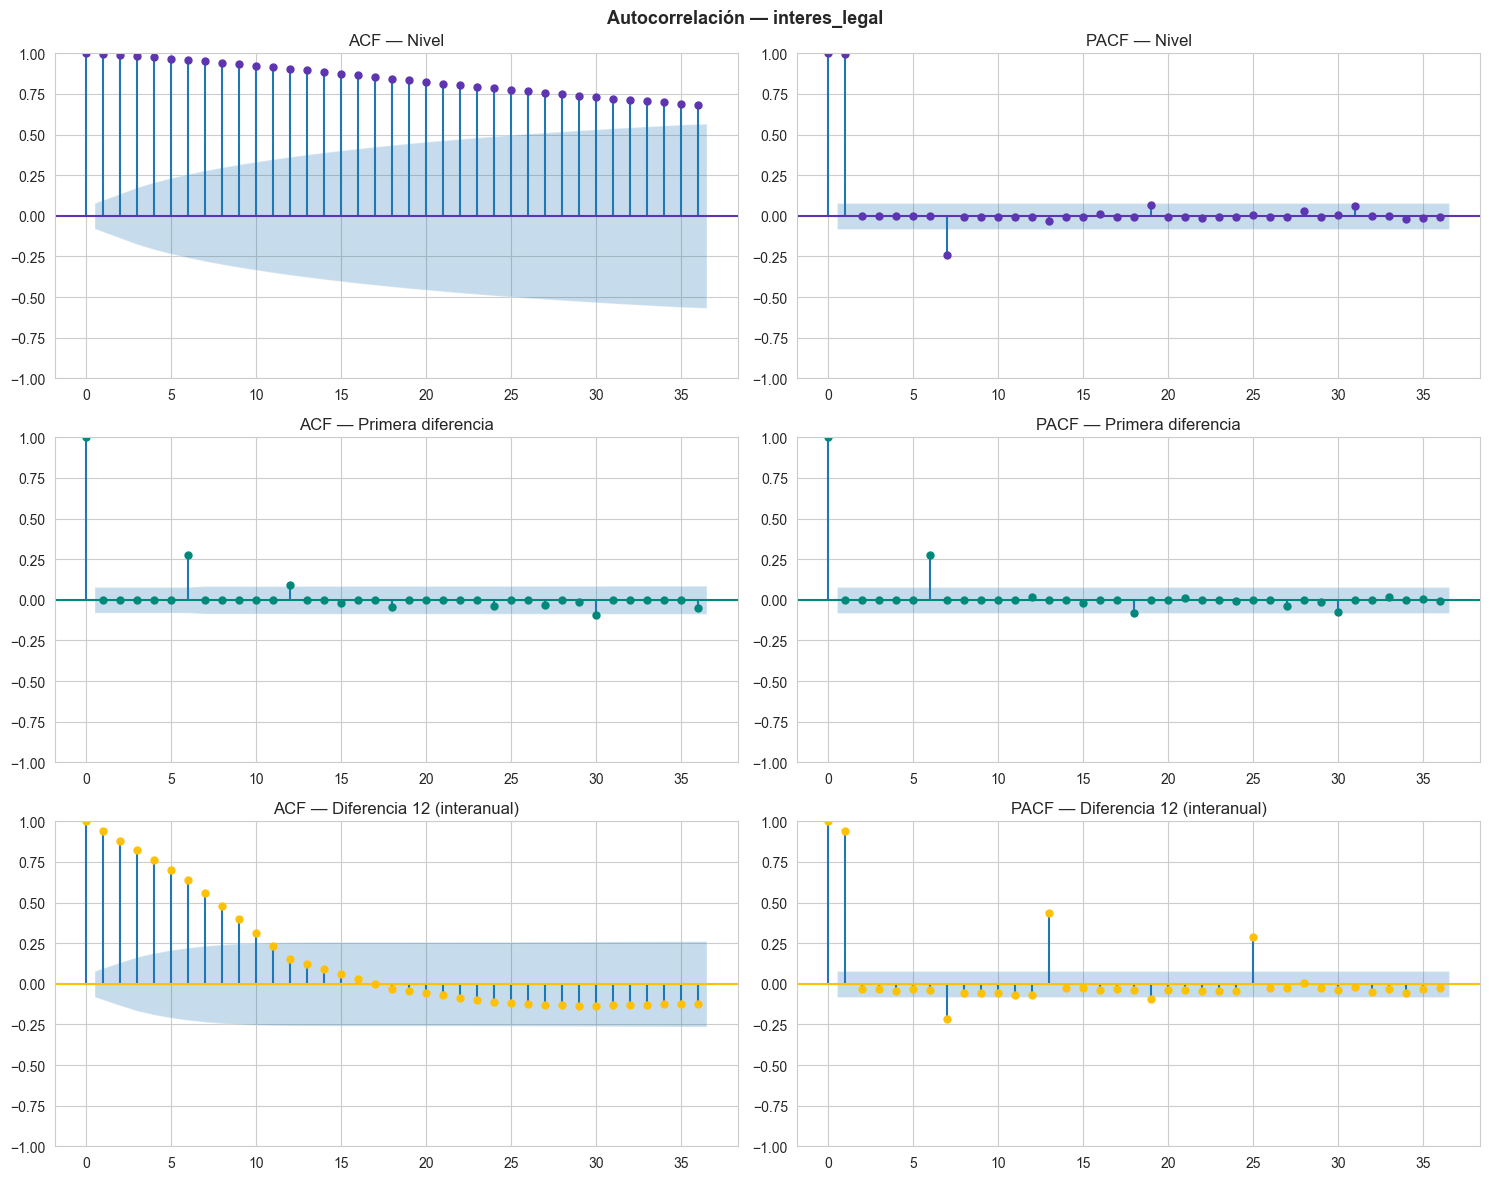

In [48]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle(f'Autocorrelación — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

plot_acf(y.dropna(), lags=LAGS_ACF, ax=axes[0, 0], color=COLOR_PRINCIPAL,
         title='ACF — Nivel')
plot_pacf(y.dropna(), lags=LAGS_ACF, ax=axes[0, 1], color=COLOR_PRINCIPAL,
          title='PACF — Nivel', method='ywm')
plot_acf(diff1.dropna(), lags=LAGS_ACF, ax=axes[1, 0], color='#00897B',
         title='ACF — Primera diferencia')
plot_pacf(diff1.dropna(), lags=LAGS_ACF, ax=axes[1, 1], color='#00897B',
          title='PACF — Primera diferencia', method='ywm')
plot_acf(diff_est.dropna(), lags=LAGS_ACF, ax=axes[2, 0], color='#FFC107',
         title=f'ACF — Diferencia {PERIODO_ESTACIONAL} (interanual)')
plot_pacf(diff_est.dropna(), lags=LAGS_ACF, ax=axes[2, 1], color='#FFC107',
          title=f'PACF — Diferencia {PERIODO_ESTACIONAL} (interanual)', method='ywm')

plt.tight_layout()
plt.show()

### Análisis:

En niveles, el patrón es el habitual de serie no estacionaria: ACF con decaimiento lento que se mantiene significativa más allá del lag 35 y PACF con un único pico dominante en el lag 1 seguido de lags prácticamente nulos, con la excepción de un pico negativo en torno al lag 7 que refleja la periodicidad aproximada de los cambios de escalón durante el periodo de mayor volatilidad de tipos.

Tras la primera diferencia, tanto la ACF como la PACF presentan un único pico significativo en el lag 6 (aproximadamente +0,27), con todos los demás lags dentro o muy próximos a la banda de significancia. Este pico aislado es el reflejo directo de la estructura discreta de la serie: cuando se produce un cambio de tipo, el efecto persiste durante el número de meses que el tipo permanece en ese nivel antes del siguiente ajuste, generando una autocorrelación residual en el lag correspondiente a la duración media entre cambios. Fuera de este pico, la diff 1 se comporta como ruido blanco, coherente con el diagnóstico de estacionariedad de los tests.

La diff 12 presenta un patrón distinto y más persistente: la ACF decae lentamente desde valores próximos a 0,90 en el lag 1 hasta valores positivos significativos más allá del lag 20, y la PACF muestra picos en los lags 1, 12 y 24. La causa es directa: como el tipo permanece constante durante periodos de hasta varios años, la diff 12 produce largas rachas de ceros interrumpidas por saltos, generando una autocorrelación positiva persistente. Por eso, entre las formas estacionarias, la diff 1 deja la serie más limpia que la diff 12 y es la adoptada. Queda documentado, no obstante, que la diferenciación pierde la información de régimen contenida en el nivel, que es lo económicamente relevante de esta variable.

### 6.1 Validación a frecuencia trimestral

El bloque previo de tests caracteriza la serie a su frecuencia original, donde la información es más rica. La modelización del paro, sin embargo, opera a frecuencia trimestral (target EPA), por lo que las transformaciones operativas deben validarse a esa misma frecuencia.

Este bloque verifica que las conclusiones sobre estacionariedad se trasladan correctamente a la serie resampleada (por valor de cierre trimestral, coherente con la naturaleza de la variable), sobre la que opera el modelo. Se evalúan las mismas cuatro transformaciones que a frecuencia original:
- nivel trimestral
- `Δ1` trimestral (cambio intertrimestral)
- `Δ4` trimestral (cambio interanual)
- variación interanual porcentual trimestral

In [49]:
# Resampleo a frecuencia trimestral
LAGS_ACF_Q = 16
METODO_Q = 'valor de cierre'
y_q = df[VAR_PRINCIPAL].resample('QS').last().dropna()

diff1_q = y_q.diff(1).dropna()
diff4_q = y_q.diff(4).dropna()
pct_q = ((y_q / y_q.shift(4) - 1) * 100).dropna()

series_test_q = [
    (y_q, f'{VAR_PRINCIPAL} trimestral (nivel)', 'ct'),
    (diff1_q, f'{VAR_PRINCIPAL} trimestral (Δ1)', 'c'),
    (diff4_q, f'{VAR_PRINCIPAL} trimestral (Δ4)', 'c'),
    (pct_q, f'{VAR_PRINCIPAL} trimestral (var interanual %)', 'c'),
]

resultados_q = pd.DataFrame([test_estacionariedad(s, n, r) for s, n, r in series_test_q])

print(f'Tests de estacionariedad — frecuencia TRIMESTRAL (resampleo: {METODO_Q}):')
print('=' * 85)
print(resultados_q.to_string(index=False))
print()
print('Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)')
for _, row in resultados_q.iterrows():
    h0_adf = 'rechaza H₀' if row['ADF_H0_rechaza'] else 'NO rechaza H₀'
    h0_kpss = 'rechaza H₀' if row['KPSS_H0_rechaza'] else 'NO rechaza H₀'
    print(f"  {row['serie']}  (KPSS regression='{row['regression']}')")
    print(f"    ADF  stat={row['ADF_stat']:.3f}, p={row['ADF_p']:.4f} ({h0_adf})")
    print(f"    KPSS stat={row['KPSS_stat']:.3f}, p={row['KPSS_p']:.4f} ({h0_kpss})")
    print(f"    → {row['conclusion']}")
    print()

Tests de estacionariedad — frecuencia TRIMESTRAL (resampleo: valor de cierre):
                                      serie regression  ADF_stat  ADF_p  ADF_H0_rechaza  KPSS_stat  KPSS_p  KPSS_H0_rechaza      conclusion
           interes_legal trimestral (nivel)         ct    -1.676  0.444           False      0.281   0.010             True NO ESTACIONARIA
              interes_legal trimestral (Δ1)          c    -7.550  0.000            True      0.145   0.100            False    ESTACIONARIA
              interes_legal trimestral (Δ4)          c    -3.244  0.018            True      0.157   0.100            False    ESTACIONARIA
interes_legal trimestral (var interanual %)          c    -3.932  0.002            True      0.187   0.100            False    ESTACIONARIA

Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)
  interes_legal trimestral (nivel)  (KPSS regression='ct')
    ADF  stat=-1.676, p=0.4436 (NO rechaza H₀)
    KPSS stat=0.281, p=0.0100 (rechaza H₀)
    → 

### Análisis:

La validación a frecuencia trimestral confirma el diagnóstico de la frecuencia mensual. El nivel sigue siendo no estacionario (ADF stat=-1,676, p=0,4436; KPSS stat=0,281, p=0,0100), con el KPSS rechazando por los saltos de nivel entre regímenes. La primera diferencia `Δ1` es estacionaria con holgura (ADF stat=-7,550, p=0,0000; KPSS stat=0,145, p=0,1000), la transformación más limpia también a esta frecuencia. La diferencia interanual `Δ4` (ADF stat=-3,244, p=0,0176; KPSS stat=0,157, p=0,1000) y la variación interanual porcentual (ADF stat=-3,932, p=0,0018; KPSS stat=0,187, p=0,1000) son igualmente estacionarias según los tests.

Ahora bien, la elección de la forma no la deciden solo los p-valores. Por tratarse de una tasa, el cambio con sentido económico es el absoluto en puntos porcentuales, no el relativo: la variación interanual porcentual de un tipo de interés carece de interpretación clara y es numéricamente inestable cuando el tipo se aproxima a cero, como en el tramo reciente. Se adopta por tanto la `Δ1`, el cambio intertrimestral en puntos, la más limpia y la natural para una tasa escalonada, descartando la variación porcentual. El nivel, no estacionario, se reserva para los modelos que operan en niveles por ser el portador del régimen monetario.

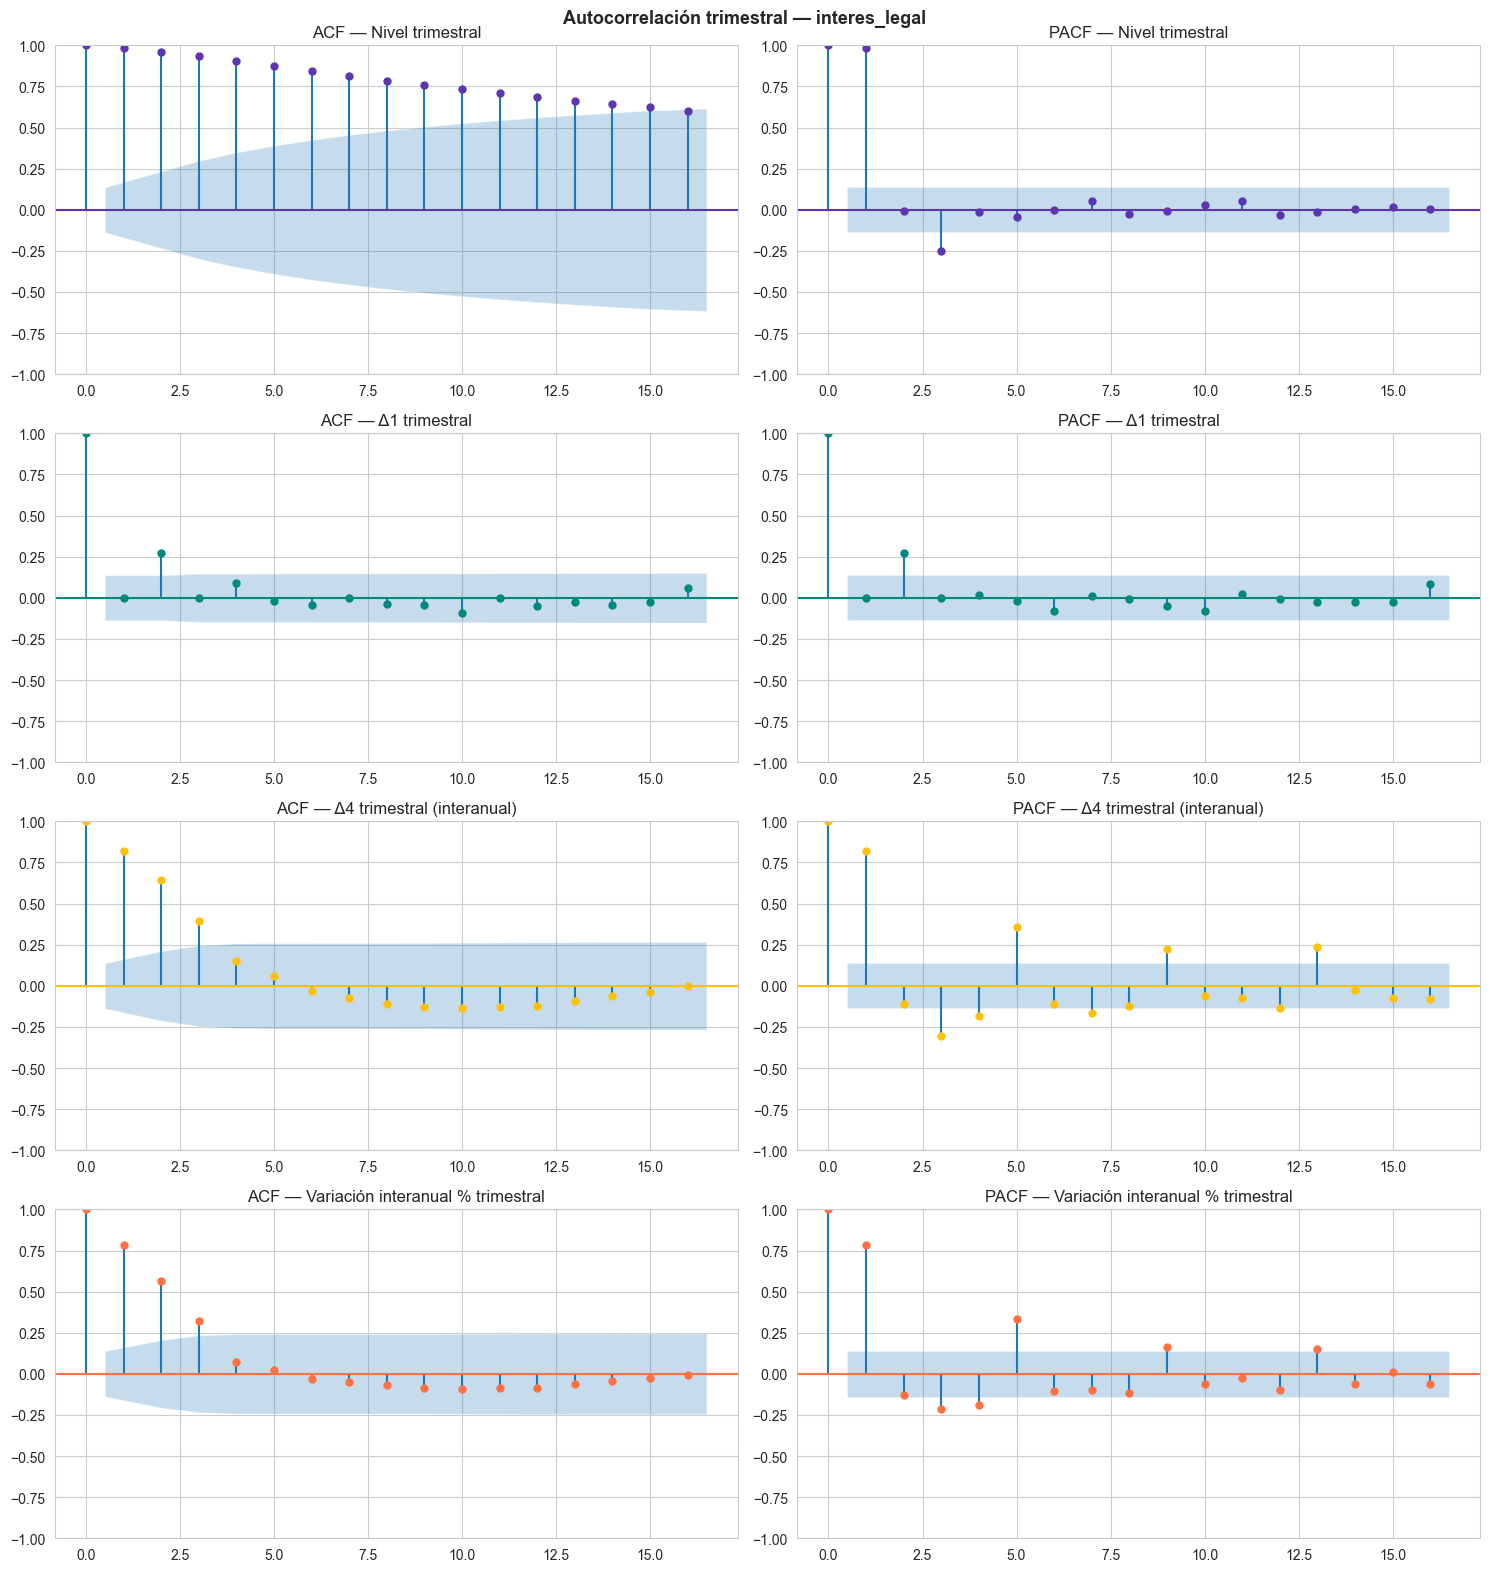

In [50]:
fig, axes = plt.subplots(4, 2, figsize=(15, 16))
fig.suptitle(f'Autocorrelación trimestral — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

plot_acf(y_q.dropna(), lags=LAGS_ACF_Q, ax=axes[0, 0], color=COLOR_PRINCIPAL,
         title='ACF — Nivel trimestral')
plot_pacf(y_q.dropna(), lags=LAGS_ACF_Q, ax=axes[0, 1], color=COLOR_PRINCIPAL,
          title='PACF — Nivel trimestral', method='ywm')
plot_acf(diff1_q, lags=LAGS_ACF_Q, ax=axes[1, 0], color='#00897B',
         title='ACF — Δ1 trimestral')
plot_pacf(diff1_q, lags=LAGS_ACF_Q, ax=axes[1, 1], color='#00897B',
          title='PACF — Δ1 trimestral', method='ywm')
plot_acf(diff4_q, lags=LAGS_ACF_Q, ax=axes[2, 0], color='#FFC107',
         title='ACF — Δ4 trimestral (interanual)')
plot_pacf(diff4_q, lags=LAGS_ACF_Q, ax=axes[2, 1], color='#FFC107',
          title='PACF — Δ4 trimestral (interanual)', method='ywm')
plot_acf(pct_q, lags=LAGS_ACF_Q, ax=axes[3, 0], color='#FF7043',
         title='ACF — Variación interanual % trimestral')
plot_pacf(pct_q, lags=LAGS_ACF_Q, ax=axes[3, 1], color='#FF7043',
          title='PACF — Variación interanual % trimestral', method='ywm')

plt.tight_layout()
plt.show()

### Análisis:

La estructura de autocorrelación a frecuencia trimestral confirma el patrón de la frecuencia mensual. En nivel, la ACF decae lentamente desde valores próximos a 1, en torno a 0,60 todavía en el lag 16, y la PACF concentra la señal en un pico dominante en el lag 1, la firma de un AR(1) con raíz próxima a 1 propia de una serie no estacionaria, con un pico negativo aislado en el lag 3 que refleja la periodicidad aproximada de los cambios de escalón.

La primera diferencia `Δ1` es la transformación más próxima al ruido blanco: su ACF y su PACF solo muestran un pico modesto en el lag 2 (aproximadamente +0,27) y el resto de lags caen dentro de la banda, coherente con una serie cuya variación es nula salvo en los escasos cambios por decreto. La diferencia interanual `Δ4` y la variación interanual porcentual presentan, en cambio, mayor persistencia: ambas parten de un lag 1 elevado (aproximadamente +0,80) y decaen de forma gradual, con la PACF mostrando picos adicionales, reflejo de las largas rachas de valores constantes que el filtro interanual arrastra. Las tres son estacionarias según los tests, pero la `Δ1` es la que deja la serie más limpia, lo que refuerza su elección como forma de cruce.

In [51]:
# Estacionalidad trimestral reconstruida desde y_q
if len(y_q) >= 8:
    colores_bp = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107']
    df_box_q = pd.DataFrame({
        'trimestre': y_q.index.quarter.map({1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'}),
        'valor': y_q.values,
        'fecha': y_q.index.strftime('%Y-%m-%d'),
    })
    df_box_q['trimestre'] = pd.Categorical(df_box_q['trimestre'],
                                            categories=['Q1', 'Q2', 'Q3', 'Q4'], ordered=True)
    fig = px.box(
        df_box_q, x='trimestre', y='valor', color='trimestre',
        hover_data=['fecha'],
        title=f'Estacionalidad trimestral — {VAR_PRINCIPAL}',
        labels={'valor': UNIDADES, 'trimestre': 'Trimestre'},
        color_discrete_sequence=colores_bp,
    )
    fig.update_layout(showlegend=False, height=420)
    fig.show()

    medias_q = y_q.groupby(y_q.index.quarter).mean()
    cv_trimestral = medias_q.std() / medias_q.mean() * 100 if medias_q.mean() != 0 else 0
    medias_dict = {k: round(float(v), 3) for k, v in medias_q.items()}
    print('Media por trimestre:', medias_dict)
    estac = '(estacionalidad apreciable)' if cv_trimestral > 5 else '(estacionalidad leve)'
    print(f'CV entre trimestres: {cv_trimestral:.2f}% {estac}')

Media por trimestre: {1: 5.343, 2: 5.333, 3: 5.385, 4: 5.385}
CV entre trimestres: 0.50% (estacionalidad leve)


### Análisis:

La estacionalidad trimestral del `interes_legal` es prácticamente nula. Las cuatro cajas son visualmente indistinguibles en mediana, rango intercuartílico y bigotes, y las medias por trimestre se separan por menos de seis centésimas (Q1 5,343, Q2 5,333, Q3 5,385, Q4 5,385), con un coeficiente de variación entre trimestres de apenas 0,50%, el más bajo del proyecto junto al del tipo de cambio. Es el resultado esperado para un tipo regulado que se fija con carácter anual y permanece constante dentro de cada ejercicio presupuestario, sin mecanismo económico que genere un patrón intraanual. El resampleo trimestral por valor de cierre no introduce ni elimina variación estacional.

---
## 7. Variables Derivadas Intra-Dataset
Ratios y transformaciones calculadas a partir de las columnas de este dataset.

In [52]:
df_der = pd.DataFrame(index=df.index)

if all(c in df.columns for c in ['interes_demora_efectos_tributarios', 'interes_legal']):
    df_der['diferencial'] = df['interes_demora_efectos_tributarios'] - df['interes_legal']

df_der['cambio_tipo'] = df['interes_legal'].diff()

print(f'Variables derivadas creadas ({len(df_der.columns)}):')
display(df_der.describe().round(3))

Variables derivadas creadas (2):


,diferencial,cambio_tipo
count,616.000,615.000
mean,1.792,-0.001
std,1.110,0.267
min,0.000,-2.000
25%,1.000,0.000
50%,1.250,0.000
75%,2.500,0.000
max,4.000,4.000


### Análisis:

Se han construido dos variables derivadas del `interes_legal`, ambas orientadas a capturar dimensiones distintas de la dinámica de tipos regulados.

`diferencial` (spread entre `interes_demora_efectos_tributarios` e `interes_legal`) presenta una media de 1,792 puntos porcentuales y una mediana de 1,250, con un rango de 0 a 4 puntos. La distancia entre media y mediana refleja la asimetría documentada en el análisis del spread: el diferencial era más amplio en el periodo de tipos altos, hasta 4 puntos en 1975-1984, y se ha comprimido progresivamente hasta valores de 0,75-1,00 en el tramo reciente. Los percentiles 25 y 75 (1,000 y 2,500) capturan los dos regímenes principales de diferencial.

`cambio_tipo` (primera diferencia mensual del `interes_legal`) confirma cuantitativamente lo ya documentado en el análisis de cambios periodo a periodo: la mediana de 0,000 y los percentiles 25 y 75 ambos en 0,000 indican que en más del 50% de los meses no se produce ningún cambio de tipo. La media de -0,001 es prácticamente nula, coherente con la reversión de largo plazo de la serie entre sus dos regímenes. El rango entre -2,000 y +4,000 recoge los escalones máximos de descenso y ascenso documentados en la serie principal. Su información relevante no está en el nivel sino en la fecha y magnitud de cada cambio discreto, un rasgo que queda documentado y cuyo aprovechamiento se difiere a la fase de feature engineering.

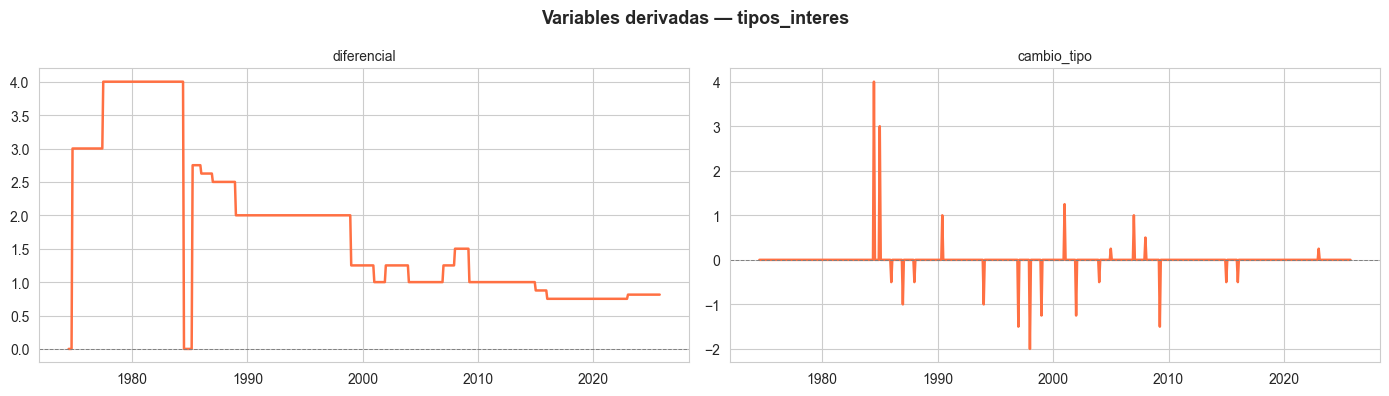

In [53]:
if not df_der.empty and len(df_der.columns) > 0:
    ncols = min(2, len(df_der.columns))
    nrows = (len(df_der.columns) + 1) // 2

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = np.array(axes).flatten() if nrows * ncols > 1 else [axes]
    fig.suptitle(f'Variables derivadas — {NOMBRE}', fontsize=13, fontweight='bold')

    for ax, col in zip(axes, df_der.columns):
        serie = df_der[col].dropna()
        ax.plot(serie.index, serie, color='#FF7043', lw=1.8)
        ax.axhline(0, color='gray', lw=0.7, linestyle='--')
        ax.set_title(col, fontsize=10)

    for ax in axes[len(df_der.columns):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

### Análisis:

La representación temporal de las dos variables derivadas confirma los estadísticos descriptivos y añade la dimensión temporal necesaria para interpretar su utilidad.

`diferencial` describe la trayectoria descendente ya documentada en el análisis del spread: parte de 3,0-4,0 puntos en 1975-1984, se comprime hasta valores de 2,0-2,75 puntos durante el régimen de tipos altos de 1985-1995, y converge hacia una banda estable de 0,75-1,00 puntos desde aproximadamente 2015. El único episodio anómalo es el descenso transitorio a 0 puntos en torno a 1985, que corresponde al momento en que el salto del tipo legal fue mayor que el del tipo de demora y el spread se comprimió momentáneamente antes de recuperarse. La tendencia descendente monótona implica que esta variable tampoco es estacionaria en nivel, aunque su variación es lenta.

`cambio_tipo` confirma visualmente la escasez de cambios: la serie es cero durante la práctica totalidad de la muestra, con barras que aparecen únicamente en momentos puntuales. El pico positivo de +4 en 1985 es el cambio más extremo de toda la serie, y los descensos más pronunciados de -1 y -2 puntos se concentran en el periodo de convergencia 1995-2000 y en los ajustes posteriores a la crisis de 2009-2012. La estructura de impulsos aislados sobre una base de ceros confirma que la información relevante de esta variable está en la fecha y magnitud de cada cambio discreto, no en una trayectoria continua.

In [54]:
# ── Guardar dataset enriquecido (trimestral) ───────────────────────────────────────
if not df_der.empty:
    for col in df_der.columns:
        df[col] = df_der[col]

# Remuestrear a frecuencia trimestral
cols_num = [c for c in df.columns if df[c].dtype in ['float64', 'int64', 'float32']]
df_trimestral = df[cols_num].resample('QS').last()
df_trimestral = df_trimestral.dropna(how='all')

# Guardar CSV trimestral
ruta_q = ruta.parent / (ruta.stem + '_trimestral.csv')
df_trimestral.to_csv(ruta_q)
print(f'CSV trimestral guardado: {ruta_q.name}')
print(f'  Columnas: {len(df_trimestral.columns)}')
print(f'  Rango: {df_trimestral.index.min().date()} — {df_trimestral.index.max().date()}')
print(f'  Observaciones: {len(df_trimestral)} trimestres')


CSV trimestral guardado: interes_legal_interes_demora_tributaria_trimestral.csv
  Columnas: 6
  Rango: 1974-07-01 — 2025-10-01
  Observaciones: 206 trimestres


### Análisis:

Como ya mostraba el boxplot trimestral, la estacionalidad trimestral del `interes_legal` es negligible. Las medias por trimestre son prácticamente idénticas (Q1 5,343, Q2 5,333, Q3 5,385, Q4 5,385), con un coeficiente de variación entre trimestres de apenas 0,50%. Las cuatro cajas son visualmente indistinguibles, resultado esperado para un tipo regulado que se fija anualmente y permanece constante dentro de cada ejercicio presupuestario. El resampleo trimestral por valor de cierre no introduce ni elimina variación estacional artificial.

---
## 8. Tabla Resumen

In [55]:
est_q_nivel = resultados_q[resultados_q['serie'].str.contains('nivel')]['conclusion'].values[0]
est_q_d1 = resultados_q[resultados_q['serie'].str.contains('Δ1')]['conclusion'].values[0]
est_q_d4 = resultados_q[resultados_q['serie'].str.contains('Δ4')]['conclusion'].values[0]
est_q_pct = resultados_q[resultados_q['serie'].str.contains('var interanual')]['conclusion'].values[0]

if DATASET_CONFIG['frecuencia_original'] in ('trimestral', 'mensual'):
    idx_max = indice_estacional.idxmax()
    idx_min = indice_estacional.idxmin()
else:
    idx_max = 'N/A'
    idx_min = 'N/A'

q1q, q3q = y_q.quantile(0.25), y_q.quantile(0.75)
iqr_q = q3q - q1q
outliers_q = y_q[(y_q < q1q - 1.5 * iqr_q) | (y_q > q3q + 1.5 * iqr_q)]

resumen = pd.DataFrame([{
    'Dataset':               NOMBRE,
    'Variable':              VAR_PRINCIPAL,
    'Frecuencia':            f'trimestral (resampleo: {METODO_Q})',
    'N obs original':        f"{len(y.dropna())} ({DATASET_CONFIG['frecuencia_original']})",
    'Rango':                 f'{y_q.index.min().date()} — {y_q.index.max().date()}',
    'N obs':                 len(y_q.dropna()),
    'Media':                 y_q.mean().round(2),
    'Mediana':               y_q.median().round(2),
    'Std':                   y_q.std().round(2),
    'CV (%)':                (y_q.std() / y_q.mean() * 100).round(1),
    'Mín (fecha)':           f'{y_q.min():.1f} ({y_q.idxmin().date()})',
    'Máx (fecha)':           f'{y_q.max():.1f} ({y_q.idxmax().date()})',
    'Outliers IQR':          len(outliers_q),
    '% faltantes (original)': f'{df[VAR_PRINCIPAL].isnull().mean()*100:.1f}%',
    'Estacionaria (nivel)':            est_q_nivel,
    'Estacionaria (Δ1)':               est_q_d1,
    'Estacionaria (Δ4)':               est_q_d4,
    'Estacionaria (var interanual %)': est_q_pct,
    'Periodo más alto':      idx_max,
    'Periodo más bajo':      idx_min,
}]).T

resumen.columns = ['Valor']
print('=' * 60)
print('TABLA RESUMEN (frecuencia trimestral)')
print('=' * 60)
print(resumen.to_string())

TABLA RESUMEN (frecuencia trimestral)
                                                                   Valor
Dataset                                                    tipos_interes
Variable                                                   interes_legal
Frecuencia                       trimestral (resampleo: valor de cierre)
N obs original                                             616 (mensual)
Rango                                            1974-07-01 — 2025-10-01
N obs                                                                206
Media                                                              5.360
Mediana                                                            4.000
Std                                                                2.540
CV (%)                                                            47.300
Mín (fecha)                                             3.0 (2016-01-01)
Máx (fecha)                                            11.0 (1985-01-01)
Outliers IQR 

### Análisis:

La tabla resumen del `interes_legal` recoge los estadísticos principales sobre 616 observaciones mensuales entre julio de 1974 y octubre de 2025 (206 trimestres tras el resampleo por valor de cierre), sin valores faltantes y sin outliers por criterio IQR. La media de 5,360% supera notablemente a la mediana de 4,000%, reflejo de la distribución bimodal entre el régimen de tipos bajos (3-4%) y el de tipos altos (9-11%). El coeficiente de variación de 47,3% es elevado pero no refleja volatilidad sino la distancia estructural entre ambos regímenes monetarios.

El diagnóstico de estacionariedad fija la forma de la variable, y conviene precisarlo porque el `interes_legal` es un caso distinto de las variables anteriores. El nivel no es estacionario, al ser una serie escalonada con saltos de régimen, pero es la representación económicamente más informativa: cada escalón define un régimen monetario persistente, y por eso el nivel se reserva como input para los modelos que operan sobre niveles (Prophet y VECM). La primera diferencia `Δ1` y la diferencia interanual `Δ4` son estacionarias; entre ellas se adopta la `Δ1`, el cambio intertrimestral en puntos porcentuales, como forma para el grupo de modelos que exigen estacionariedad y para el cruce con el paro. No se usa la variación interanual porcentual: por tratarse de una tasa, el cambio relevante es el absoluto en puntos, y el cambio porcentual de un tipo carece de interpretación económica y es inestable cuando el tipo se acerca a cero. La `Δ1` es además la transformación con el correlograma más limpio (casi ruido blanco), si bien su utilidad como regresor es limitada porque es nula en la mayoría de los trimestres.

---
## 9. Análisis Cruzado con Desempleo
Relación entre **Tipos Interes** y el desempleo (EPA, desde 1976Q3).

In [56]:
ruta_parados_s9 = RUTA_BASE / 'parados_sexo_edad.csv'
df_par_s9 = pd.read_csv(ruta_parados_s9)
df_par_s9['fecha'] = pd.to_datetime(df_par_s9['fecha'])
df_par_s9 = df_par_s9.set_index('fecha').sort_index()
df_par_s9['tasa_paro_ambos_sexos_total'] = pd.to_numeric(
    df_par_s9['tasa_paro_ambos_sexos_total'], errors='coerce')

parados_aligned = df_par_s9['tasa_paro_ambos_sexos_total']
fecha_inicio_comun = max(parados_aligned.first_valid_index(), df.index.min())
parados_aligned = parados_aligned[parados_aligned.index >= fecha_inicio_comun]
df_resampled = df[[VAR_PRINCIPAL]].resample('QS').agg('last').dropna()

# ── Qué variable cruzar con desempleo ──────────────────────────
main_s9 = df_resampled[VAR_PRINCIPAL].diff(1)                    # primera diferencia intertrimestral
main_s9_label = f'Δ1 {VAR_PRINCIPAL}'                            #
main_s9 = main_s9[main_s9.index >= fecha_inicio_comun].dropna()

print(f'Variable de cruce: {main_s9_label}')
print(f'Periodo común: {fecha_inicio_comun.date()} en adelante')
print(f'Observaciones alineadas: {len(main_s9)}')

Variable de cruce: Δ1 interes_legal
Periodo común: 1976-07-01 en adelante
Observaciones alineadas: 198


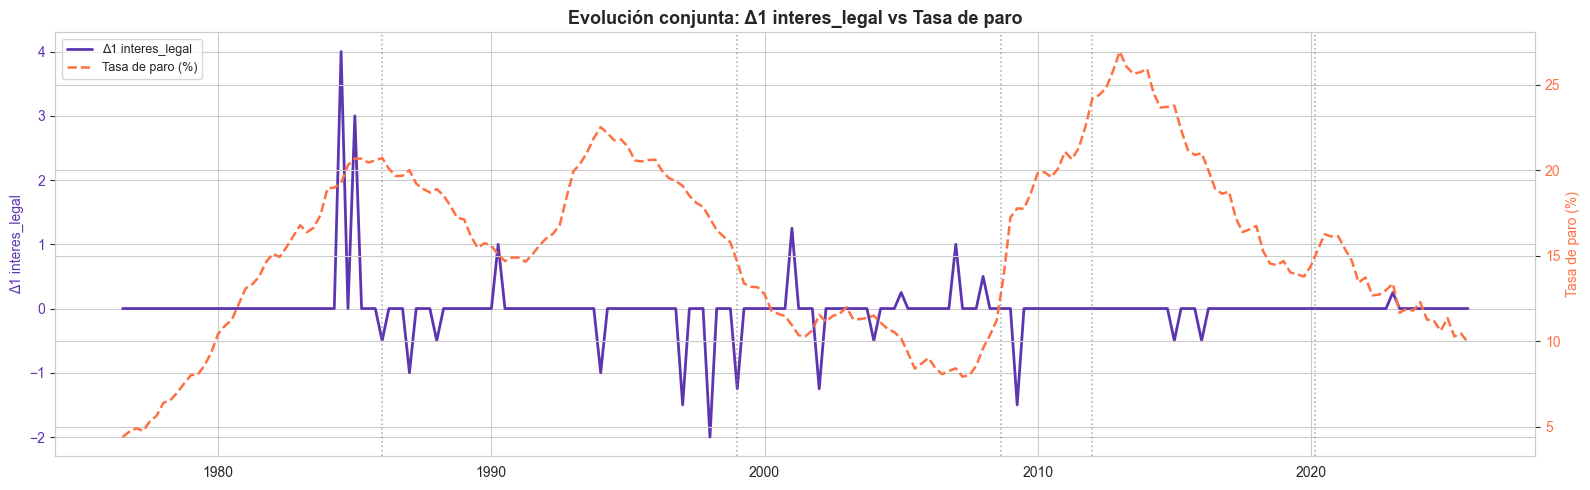

In [57]:
fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()

ax1.plot(main_s9.index, main_s9, color=COLOR_PRINCIPAL, lw=2,
         label=main_s9_label)
ax2.plot(parados_aligned.index, parados_aligned, color='#FF7043',
         lw=1.8, linestyle='--', label='Tasa de paro (%)')

ax1.set_ylabel(main_s9_label, color=COLOR_PRINCIPAL, fontsize=10)
ax2.set_ylabel('Tasa de paro (%)', color='#FF7043', fontsize=10)
ax1.tick_params(axis='y', labelcolor=COLOR_PRINCIPAL)
ax2.tick_params(axis='y', labelcolor='#FF7043')

for fecha_str, texto in EVENTOS.items():
    fecha_ev = pd.Timestamp(fecha_str)
    if main_s9.index.min() <= fecha_ev <= main_s9.index.max():
        ax1.axvline(fecha_ev, color='gray', linestyle=':', lw=1.2, alpha=0.6)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')
ax1.set_title(f'Evolución conjunta: {main_s9_label} vs Tasa de paro', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Análisis:

La evolución conjunta de la primera diferencia del `interes_legal` y la tasa de paro pone de manifiesto que los cambios del tipo legal son episodios escasos y discretos, sin co-movimiento con los ciclos del desempleo. La `Δ1` del tipo es cero durante la práctica totalidad de la muestra, porque el tipo permanece fijo dentro de cada ejercicio, y solo presenta impulsos en los momentos de cambio por decreto: el salto de +4 puntos de 1985, los descensos escalonados de 1988-2000 y los ajustes menores posteriores. Frente a esa señal casi siempre nula, la tasa de paro recorre sus tres grandes ciclos, con picos de 21% en 1985, 24% en 1994 y 27% en 2013.

Esta estructura de impulsos aislados sobre una base de ceros implica que, a diferencia del nivel, la variación del tipo no traza ninguna trayectoria comparable con la del paro: los cambios del tipo se concentran en el régimen de tipos altos de 1985-1998 y en la convergencia hacia el euro, mientras los grandes movimientos del desempleo posteriores a 2008 ocurren con el tipo prácticamente estable. La sección cuantitativa siguiente confirma que la correlación entre la variación del tipo y el paro es esencialmente nula, en contraste con la correlación positiva del nivel, que era una coincidencia de regímenes.

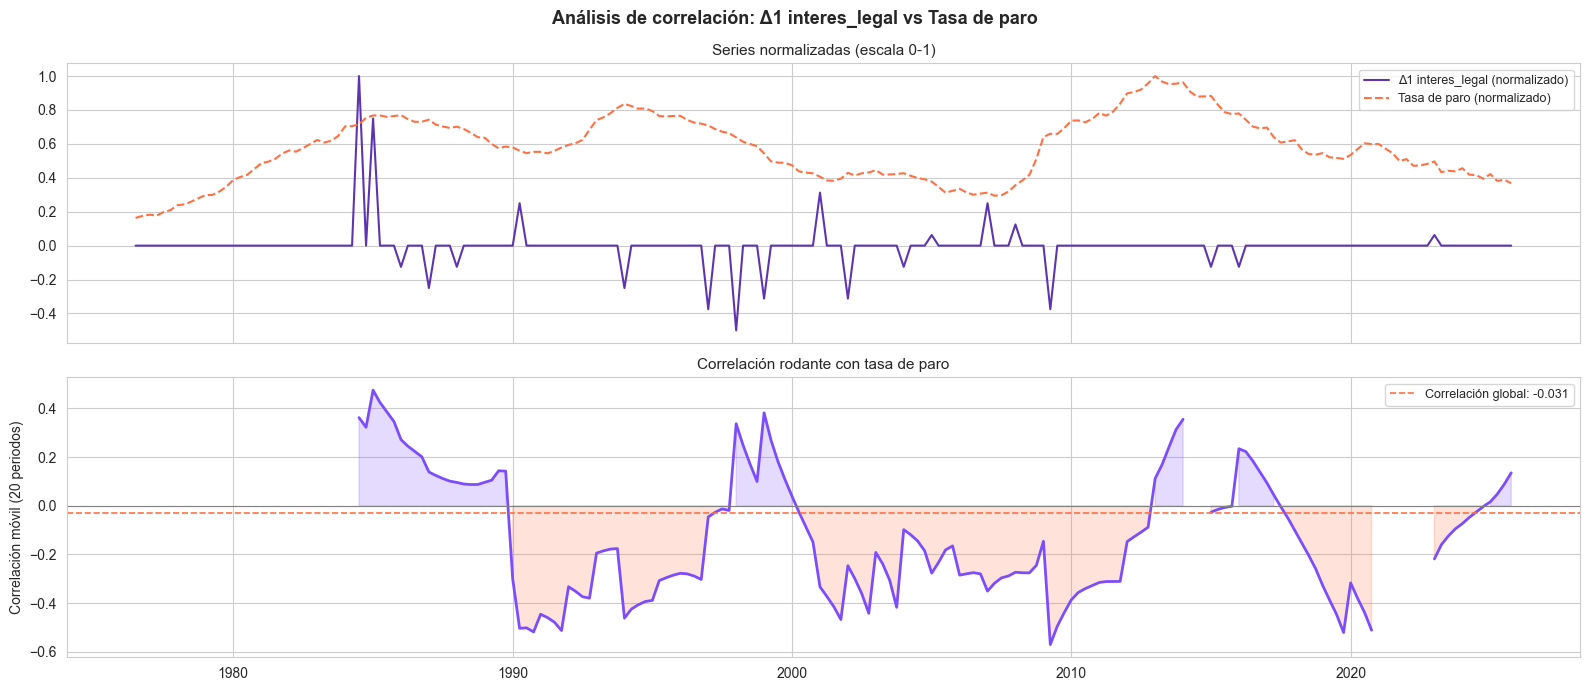

Correlación de Pearson global: -0.0305


In [58]:
ventana_corr = 20

df_cross = pd.DataFrame({'tipos_interes': main_s9, 'parados': parados_aligned}).dropna()
rolling_corr = df_cross['tipos_interes'].rolling(ventana_corr).corr(df_cross['parados'])
corr_global = df_cross['tipos_interes'].corr(df_cross['parados'])

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

axes[0].plot(df_cross.index, df_cross['tipos_interes'] / df_cross['tipos_interes'].max(),
             color=COLOR_PRINCIPAL, lw=1.5, label=f'{main_s9_label} (normalizado)')
axes[0].plot(df_cross.index, df_cross['parados'] / df_cross['parados'].max(),
             color='#FF7043', lw=1.5, linestyle='--', label='Tasa de paro (normalizado)')
axes[0].legend(fontsize=9)
axes[0].set_title('Series normalizadas (escala 0-1)', fontsize=11)

axes[1].plot(rolling_corr.index, rolling_corr, color='#7C4DFF', lw=2)
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].axhline(corr_global, color='#FF7043', lw=1.2, linestyle='--',
                label=f'Correlación global: {corr_global:.3f}')
axes[1].fill_between(rolling_corr.index, rolling_corr, 0,
                      where=rolling_corr > 0, alpha=0.2, color='#7C4DFF')
axes[1].fill_between(rolling_corr.index, rolling_corr, 0,
                      where=rolling_corr < 0, alpha=0.2, color='#FF7043')
axes[1].set_ylabel(f'Correlación móvil ({ventana_corr} periodos)', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].set_title('Correlación rodante con tasa de paro', fontsize=11)

fig.suptitle(f'Análisis de correlación: {main_s9_label} vs Tasa de paro', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Correlación de Pearson global: {corr_global:.4f}')

### Análisis:

La correlación global entre la `Δ1` del `interes_legal` y la tasa de paro es de -0,0305, prácticamente nula. El contraste con la correlación del nivel, que era de +0,346, positiva y moderada, es la confirmación cuantitativa de que aquella era espuria: la inducía la coincidencia temporal entre el régimen de tipos altos (1985-1998) y el periodo de desempleo estructuralmente elevado, no una relación entre la política de tipos y el empleo. Al diferenciar y quedarnos solo con los cambios efectivos del tipo, esa coincidencia desaparece y la asociación contemporánea se desvanece.

La correlación rodante a 20 trimestres oscila de forma inestable entre aproximadamente +0,45 y -0,55, con predominio de tramos negativos en 1990-1996, 2001-2012 y 2019-2021, y tramos positivos en 1984-1988, 1998-2000 y 2013-2016. Esta inestabilidad es consecuencia directa de la naturaleza escalonada de la serie: como la `Δ1` es nula casi siempre, cada ventana de correlación queda determinada por los pocos cambios de tipo que contiene, lo que produce oscilaciones de signo sin un patrón económico estable. La correlación global cercana a cero es el promedio de esos tramos de signo opuesto.

Para la caracterización de la variable, el resultado es claro: la variación del tipo legal no guarda relación contemporánea apreciable con el paro. La información económicamente relevante reside en su nivel, que define el régimen monetario, no en su variación; ese nivel queda disponible para los modelos que operan sobre series no estacionarias, mientras su aprovechamiento se difiere a la fase de feature engineering.

In [59]:
df_cross['decada'] = (df_cross.index.year // 10 * 10).astype(str) + 's'
paleta_decadas = ['#1565C0', '#00897B', '#FF7043', '#7C4DFF', '#FFC107', '#AD1457']

df_scatter = df_cross.reset_index().rename(columns={'index': 'fecha', df_cross.index.name or 'index': 'fecha'})
if 'fecha' not in df_scatter.columns:
    df_scatter.insert(0, 'fecha', df_cross.index.strftime('%Y-%m-%d'))
else:
    df_scatter['fecha'] = pd.to_datetime(df_scatter['fecha']).dt.strftime('%Y-%m-%d')

fig = px.scatter(
    df_scatter, x='tipos_interes', y='parados',
    color='decada',
    hover_data=['fecha'],
    trendline='ols',
    trendline_scope='overall',
    color_discrete_sequence=paleta_decadas,
    title=f'Dispersión por década: {main_s9_label} vs Desempleo',
    labels={
        'tipos_interes': main_s9_label,
        'parados': 'Tasa de paro (%)',
        'decada': 'Década', 'fecha': 'Fecha',
    },
)
fig.for_each_trace(lambda t: t.update(name='Tendencia global') if t.name == 'Overall Trendline' else None)
fig.update_traces(marker=dict(size=6, opacity=0.75))
fig.update_layout(height=520)
fig.show()

### Análisis:

El diagrama de dispersión por década confirma visualmente la correlación nula entre la variación del tipo y el paro. La estructura escalonada de la serie concentra la inmensa mayoría de las observaciones en una única columna vertical sobre `Δ1` = 0, los trimestres sin cambio de tipo, dentro de la cual el paro recorre todo su rango histórico, del 5% al 27%, para una misma variación nula del tipo. Los pocos puntos fuera de esa columna corresponden a los trimestres con cambio por decreto y se reparten entre -2 y +4 puntos sin alinearse con ningún nivel concreto de paro.

La recta de tendencia global es casi horizontal, con una pendiente ligeramente negativa que arrastran los escasos puntos no nulos, sin valor interpretativo. La lectura es inequívoca: dado que la variación del tipo legal es cero en la mayor parte de la muestra y los cambios son episodios aislados, no existe relación lineal entre ese cambio y la tasa de paro. La señal de esta variable, de existir, está en el nivel del tipo y no en su diferencia.

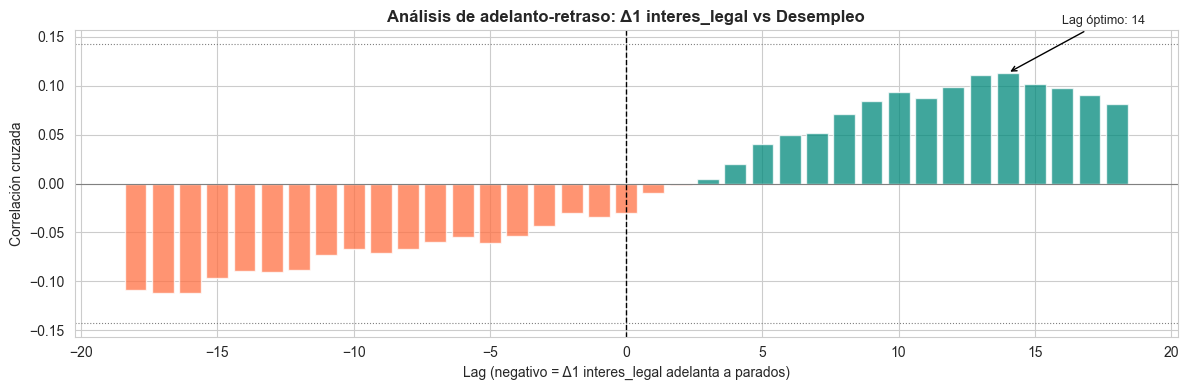

Lag con máxima correlación: 14 periodos
Correlación en ese lag: 0.1129
Banda de significancia (±2/√N): ±0.1421


In [60]:
max_lag = LAGS_ACF // 2

sa = (df_cross['tipos_interes'] - df_cross['tipos_interes'].mean()) / df_cross['tipos_interes'].std()
sb = (df_cross['parados'] - df_cross['parados'].mean()) / df_cross['parados'].std()

lags_range = range(-max_lag, max_lag + 1)
ccf_vals = [sa.corr(sb.shift(-lag)) for lag in lags_range]

fig, ax = plt.subplots(figsize=(12, 4))
colors_ccf = ['#00897B' if v > 0 else '#FF7043' for v in ccf_vals]
ax.bar(list(lags_range), ccf_vals, color=colors_ccf, alpha=0.75)
ax.axhline(0, color='gray', lw=0.8)
ax.axvline(0, color='black', lw=1, linestyle='--')
sig = 2 / np.sqrt(len(df_cross))
ax.axhline(sig, color='gray', lw=0.8, linestyle=':')
ax.axhline(-sig, color='gray', lw=0.8, linestyle=':')

lag_max = list(lags_range)[np.argmax(np.abs(ccf_vals))]
ax.annotate(f'Lag óptimo: {lag_max}', xy=(lag_max, ccf_vals[lag_max + max_lag]),
            xytext=(lag_max + 2, ccf_vals[lag_max + max_lag] + 0.05),
            fontsize=9, arrowprops=dict(arrowstyle='->', color='black'))

ax.set_xlabel(f'Lag (negativo = {main_s9_label} adelanta a parados)', fontsize=10)
ax.set_ylabel('Correlación cruzada', fontsize=10)
ax.set_title(f'Análisis de adelanto-retraso: {main_s9_label} vs Desempleo', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Lag con máxima correlación: {lag_max} periodos')
print(f'Correlación en ese lag: {ccf_vals[lag_max + max_lag]:.4f}')
print(f'Banda de significancia (±2/√N): ±{sig:.4f}')

### Análisis:

El análisis de adelanto-retraso confirma la ausencia de relación significativa entre la variación del interés legal y la tasa de paro a cualquier horizonte. Ninguna barra del espectro, entre los lags -18 y +18, supera la banda de significancia de ±0,1421: las correlaciones son negativas y débiles en los lags negativos, hasta aproximadamente -0,11, donde la variación del tipo adelantaría al paro, y positivas y débiles en los positivos, con un máximo de apenas 0,1129 en el lag óptimo de +14, todavía por debajo del umbral de significancia.

Que ni siquiera el lag óptimo alcance la banda significativa es el resultado más concluyente: la diferencia del tipo legal no tiene poder predictivo sobre el paro en ningún horizonte, ni a corto ni a medio plazo. Es coherente con la naturaleza escalonada de la serie, cuya variación es nula salvo en los escasos momentos de cambio por decreto, y con la correlación global prácticamente nula. La utilidad de esta variable, si la tiene, reside en su nivel como indicador de régimen monetario, no en su variación; cualquier explotación de esa información se difiere a la fase de feature engineering.